# **GeoMarket AI — Notebook 01: DBSCAN Spatial Clustering**

**Tujuan notebook ini:**  
Menghasilkan `cluster_id` untuk setiap titik lokasi usaha di Batam menggunakan algoritma DBSCAN berbasis kepadatan spasial. Output `cluster_id` ini akan menjadi salah satu **fitur input utama** untuk training Random Forest di notebook berikutnya.

**Catatan penting:**  
Notebook ini dijalankan **per database** (satu DB per run) untuk mengurangi noise lintas sumber.

**Ringkasan pipeline (caption per tahap):**
- **Tahap 1** — Install & import library
- **Tahap 2** — EDA: scan file, cek skema, mapping kolom, merge data, verifikasi
- **Tahap 3** — Konfigurasi & konstanta (parameter DBSCAN dan path)
- **Tahap 4** — Ingestion & validation gate (data quality report)
- **Tahap 5** — Preprocessing & konversi koordinat (WGS84 -> UTM)
- **Tahap 6** — DBSCAN clustering + evaluasi + fitur turunan
- **Tahap 7** — Visualisasi hasil clustering & tuning EPS
- **Tahap 8** — Simpan ke feature store
- **Tahap 9** — Quality gate DBSCAN
- **Tahap 10** — Random Forest training (label proxy + evaluasi + SHAP)

**Posisi dalam MLOps Pipeline:**
```
SQLite (.db)
    └─ [01] Ingestion & Validation        <- tahap 1-2
    └─ [02] Preprocessing & Feature Eng   <- tahap 3
    └─ [03] DBSCAN Clustering             <- tahap 4-5  (inti notebook ini)
    └─ [04] Simpan ke Feature Store       <- tahap 6
            └─ [Notebook 02] Random Forest Training
```

| Algoritma | DBSCAN (Density-Based Spatial Clustering of Applications with Noise) |
|---|---|
| Input | `content/data/raw/*.db` (1 DB per run) |
| Output | `content/runs/<db_key>/data/feature_store.csv` |

**Mengapa DBSCAN harus jalan SEBELUM Random Forest?**  
Karena `cluster_id` dan `dist_to_cluster_centroid_m` adalah fitur yang hanya bisa dihasilkan setelah clustering selesai. Random Forest tidak bisa dilatih tanpa kedua fitur ini.

---

---
# Tahap 1 — Install & Import Library

Kita butuh beberapa library tambahan di luar standard library Python:
- `geopandas` + `pyproj` → untuk konversi koordinat dari derajat (WGS84) ke meter (UTM), wajib untuk perhitungan radius yang akurat
- `scikit-learn` → untuk DBSCAN dan metrik evaluasi clustering
- `scipy` → untuk perhitungan jarak spasial
- `folium` → opsional, untuk visualisasi peta interaktif

In [1]:
%pip install scikit-learn matplotlib geopandas pyproj folium seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Core ──────────────────────────────────────────────────────────────
import sqlite3
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Geospasial ────────────────────────────────────────────────────────
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point

# ── Machine Learning ──────────────────────────────────────────────────
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# ── Visualisasi ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

# Cek versi
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"geopandas   : {gpd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print("\n✓ Semua library berhasil diimport")

pandas      : 3.0.2
numpy       : 2.4.4
geopandas   : 1.1.3
scikit-learn: 1.8.0

✓ Semua library berhasil diimport


# Tahap 2 - Exploratory Data Analysis (EDA)

Tujuan: memahami struktur data, skema, dan sebaran awal sebelum validasi.

## 2.1 Scan file dataset .db

Ringkas: daftar file, kategori, dan ukuran untuk memastikan input lengkap.

In [3]:
import os
import glob

# ── Konfigurasi folder ────────────────────────────────────────────────
DB_FOLDER = "content/data/raw"

# ── Pilih satu DB untuk satu run ──────────────────────────────────────
# Isi dengan nama file .db yang akan diproses
TARGET_DB_FILE = "Indonesia.Batam.Kuliner.202406162232.db"  # contoh: "Indonesia.Batam.Kuliner.202406162232.db"

CATEGORY_MAPPING = {
    "Indonesia.Batam.Kuliner.202406162232"       : "F&B",
    "Indonesia.Batam.Kesehatan.202408050759"     : "Healthcare",
    "Indonesia.Batam.Hotel.202408042041"         : "Hospitality",
    "Indonesia.Batam.PT.202408042212"            : "Company",
    "Indonesia.Batam.School.202408060757"        : "Education",
    "Indonesia.Batam.Toko Bangunan.202408021219" : "Retail",
    "Indonesia.Batam.Cosmetics.202410290644"     : "Retail",
    "Indonesia.Batam.Toko Komputer.202410170720" : "Retail",
}

# ── Scan semua file .db (untuk validasi) ──────────────────────────────
all_db_files = sorted(glob.glob(os.path.join(DB_FOLDER, "*.db")))

if not all_db_files:
    print(f"⚠ Tidak ada file .db ditemukan di folder: {DB_FOLDER}")
    print("  Pastikan path DB_FOLDER sudah benar.")
else:
    if not TARGET_DB_FILE:
        raise ValueError("TARGET_DB_FILE belum diisi. Pilih satu file .db untuk diproses.")

    target_path = os.path.join(DB_FOLDER, TARGET_DB_FILE)
    if not os.path.exists(target_path):
        available = [os.path.basename(p) for p in all_db_files]
        raise FileNotFoundError(
            f"TARGET_DB_FILE tidak ditemukan: {TARGET_DB_FILE}\n"
            f"File tersedia: {available}"
        )

    db_files = [target_path]
    filename = os.path.basename(target_path)
    file_key = filename.replace(".db", "")
    TARGET_DB_KEY = file_key
    size_kb = os.path.getsize(target_path) / 1024

    # Lookup ke CATEGORY_MAPPING
    if file_key in CATEGORY_MAPPING:
        kategori = CATEGORY_MAPPING[file_key]
        status = "✓"
    else:
        parts = file_key.split(".")
        kategori = parts[2] if len(parts) >= 3 else "Unknown"
        status = "⚠"

    print(f"✓ Target DB: {TARGET_DB_FILE}\n")
    print(f"  {status} {filename:<47} → {kategori:<15} ({size_kb:.1f} KB)")

✓ Target DB: Indonesia.Batam.Kuliner.202406162232.db

  ✓ Indonesia.Batam.Kuliner.202406162232.db         → F&B             (4080.0 KB)


## 2.2 Peek skema tiap file

Ringkas: cek tabel user, jumlah baris, dan contoh kolom per database.

In [4]:
import sqlite3
import pandas as pd
import os
from IPython.display import display, HTML

# Daftar tabel internal SQLite yang harus selalu dilewati
SQLITE_INTERNAL_TABLES = {'sqlite_sequence', 'sqlite_stat1', 'sqlite_stat4', 'sqlite_master'}

schema_summary = []

for db_path in db_files:
    filename = os.path.basename(db_path)
    file_key = filename.replace(".db", "")
    parts = file_key.split(".")
    kategori = CATEGORY_MAPPING.get(file_key, parts[2] if len(parts) >= 3 else "Unknown")

    conn = sqlite3.connect(db_path)

    # Ambil daftar tabel
    tables_df = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
    tables = tables_df['name'].tolist()

    # Filter tabel
    user_tables = [t for t in tables if t not in SQLITE_INTERNAL_TABLES]

    # --- HEADER FILE ---
    display(HTML(f"""
    <div style="background-color: #f8f9fa; padding: 10px; border-left: 5px solid #28a745; margin-top: 20px;">
        <span style="font-weight: bold; font-size: 16px; color: #6c757d;">File: {filename}</span><br>
        <span style="color: #6c757d;">Kategori: <b>{kategori}</b> | Tabel User: {len(user_tables)}</span>
    </div>
    """))

    for table in user_tables:
        try:
            # Ambil sampel dan jumlah baris
            df_peek = pd.read_sql(f"SELECT * FROM [{table}] LIMIT 10", conn)
            row_count = pd.read_sql(f"SELECT COUNT(*) as n FROM [{table}]", conn)['n'].iloc[0]

            schema_summary.append({
                "Filename": filename,
                "Category": kategori,
                "Table": table,
                "Rows": row_count,
                "Total Column": len(df_peek.columns)
            })

            # Tampilkan info tabel dan sampel
            print(f"\n📍 Tabel: {table} ({row_count:,} baris)")
            display(df_peek)

        except Exception as e:
            print(f"  ⚠️ Gagal baca tabel '{table}': {e}")

    conn.close()

# --- BAGIAN AKHIR: RINGKASAN SELURUH FILE ---
print("\n" + "="*60)
print("📊 RINGKASAN SCHEMA KESELURUHAN")
print("="*60)

df_final_summary = pd.DataFrame(schema_summary)

if not df_final_summary.empty:
    # Format ribuan untuk tampilan profesional
    df_final_summary['Rows'] = df_final_summary['Rows'].apply(lambda x: "{:,}".format(x))
    display(df_final_summary)
else:
    print("Tidak ada tabel user yang ditemukan.")

print(f"\n✅ Inspeksi Selesai: {len(db_files)} file diproses.")


📍 Tabel: places (4,570 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,96,Pacific food court,4.4,233,2,Restaurant,"['Dine-in', 'Takeaway']","5222+C65, Jodoh River, Batu Ampar, Batam City,...",[],,1.151015,104.0006023,https://www.google.com/maps/place/Pacific+food...,2.0
1,193,Berjaya Masakan Padang,4.0,3,0,Padang restaurant,"['Dine-in', 'Takeaway']","5234+P57, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '09:00 – 21:00' }, { ...",,1.1542775,104.005409,https://www.google.com/maps/place/Berjaya+Masa...,0.0
2,211,Warung Kopi HARUM,4.4,303,0,Noodle shop,"['Dine-in', 'Takeaway']","5226+2HQ, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '06:00 – 14:00' }, { ...",,1.1500874,104.0114747,https://www.google.com/maps/place/Warung+Kopi+...,2.0
3,230,Toko Barokah,4.0,5,0,Grocery store,['In-store shopping'],"52M7+8FM, Batu Merah, Batu Ampar, Batam City, ...","[{ day: 'Sunday', hours: '07:00 – 21:00' }, { ...",,1.1833464,104.0136583,https://www.google.com/maps/place/Toko+Barokah...,2.0
4,240,Multi Bintang Indonesia,4.5,2,0,Grocery delivery service,[],"5296+42F, Batu Merah, Batu Ampar, Batam City, ...",[],,1.1678122,104.0100557,https://www.google.com/maps/place/Multi+Bintan...,3.0
5,257,Ampera nasi padang Ombak piaman,0.0,0,0,Padang restaurant,"['Dine-in', 'Takeaway']","5243+3P8, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '08:00 – 21:30' }, { ...",,1.155156,104.0043247,https://www.google.com/maps/place/Ampera+nasi+...,0.0
6,282,Pak Bas Kue & Kripic,4.0,2,0,Food products supplier,[],"52P5+VP2, Batu Merah, Batu Ampar, Batam City, ...","[{ day: 'Sunday', hours: '06:00 – 22:00' }, { ...",+62 812-7742-6621,1.1871409,104.0092639,https://www.google.com/maps/place/Pak+Bas+Kue+...,2.0
7,292,Seblak Teh Senny - Bengkong,3.4,28,0,Buffet restaurant,"['Dine-in', 'Takeaway', 'Delivery']","Pertokoan Jl. Ruko Golden City Blok F No. 6, B...","[{ day: 'Sunday', hours: '03:00 – 23:00' }, { ...",+62 821-7132-0270,1.1655638,104.0393071,https://www.google.com/maps/place/Seblak+Teh+S...,2.0
8,299,SOTO LAMONGAN CAK ALI,4.4,13,0,Soto ayam restaurant,"['Dine-in', 'Takeaway']","Komplek Maritim Square Jodoh, Blk. I No.21, RT...","[{ day: 'Sunday', hours: '11:00 – 21:00' }, { ...",,1.153548,104.0054803,https://www.google.com/maps/place/SOTO+LAMONGA...,-1.0
9,303,Bina Nusa Mandiri PT,0.0,0,0,Caterer,[],"Bukit Senyum, Batu Ampar, Komplek Malindo Cipt...",[],,1.1688287,104.0112953,https://www.google.com/maps/place/Bina+Nusa+Ma...,5.0



📊 RINGKASAN SCHEMA KESELURUHAN


,Filename,Category,Table,Rows,Total Column
0,Indonesia.Batam.Kuliner.202406162232.db,F&B,places,"4,570",14



✅ Inspeksi Selesai: 1 file diproses.


## 2.3 Definisi mapping kolom

Ringkas: samakan nama kolom kunci agar semua sumber konsisten.

In [5]:
# Setelah melihat output Cell 2.2, tentukan mapping nama kolom
# agar semua file memiliki nama kolom yang seragam setelah digabung.
#
# Ubah mapping di bawah sesuai hasil inspeksi Cell 2.2
# Key   = nama kolom ASLI di database
# Value = nama kolom STANDAR yang akan digunakan di Feature Store
#
# Kolom yang tidak ada di mapping akan tetap dipertahankan dengan
# nama aslinya.

COLUMN_MAPPING = {
    # Koordinat — sesuaikan jika nama kolom berbeda
    "lat"       : "latitude",
    "lng"       : "longitude",
    "lon"       : "longitude",
    "long"      : "longitude",

    # Nama tempat — sesuaikan jika nama kolom berbeda
    "nama"      : "name",
    "place_name": "name",
    "title"     : "name",

    # Kategori
    "cat"       : "category",
    "type"      : "category",
    "jenis"     : "category",

    # Rating & review
    "rate"      : "rating",
    "score"     : "rating",
    "ulasan"    : "reviews",
    "review_count": "reviews",
    "total_reviews": "reviews",

    # Tambahkan mapping lain sesuai kebutuhan
    # "nama_kolom_asli": "nama_kolom_standar",
}

# Kolom wajib yang harus ada setelah mapping
REQUIRED_COLS_FINAL = ["latitude", "longitude", "name", "category"]

# Nama kolom latitude & longitude yang akan digunakan (setelah mapping)
LAT_COL = "latitude"
LON_COL = "longitude"
CAT_COL = "category"

print("Mapping kolom yang akan diterapkan:")
for k, v in COLUMN_MAPPING.items():
    print(f"  '{k}' → '{v}'")
print(f"\nKolom wajib setelah mapping: {REQUIRED_COLS_FINAL}")

Mapping kolom yang akan diterapkan:
  'lat' → 'latitude'
  'lng' → 'longitude'
  'lon' → 'longitude'
  'long' → 'longitude'
  'nama' → 'name'
  'place_name' → 'name'
  'title' → 'name'
  'cat' → 'category'
  'type' → 'category'
  'jenis' → 'category'
  'rate' → 'rating'
  'score' → 'rating'
  'ulasan' → 'reviews'
  'review_count' → 'reviews'
  'total_reviews' → 'reviews'

Kolom wajib setelah mapping: ['latitude', 'longitude', 'name', 'category']


## 2.4 Gabungkan semua .db jadi Dataframe

Ringkas: load seluruh tabel dan gabungkan ke satu DataFrame.

Memulai proses penggabungan data (single DB)...

📊 LAPORAN AUDIT DATA:


,File Name,Category,Table,Rows Raw,Rows Kept,Rows Dropped
0,Indonesia.Batam.Kuliner.202406162232.db,F&B,places,4570,4206,364



JUMLAH BARIS KONSISTEN
------------------------------------------------------------
Total Baris di DataFrame : 4,206
Total Baris Raw (Sum)    : 4,570
Total Baris Kept (Sum)   : 4,206
------------------------------------------------------------

Tabel distribusi kategori (Top 10):


,Kategori,Jumlah
0,Restaurant,1290
1,Indonesian restaurant,253
2,Padang restaurant,169
3,Seafood restaurant,148
4,Bakso restaurant,147
5,Diner,138
6,Noodle shop,114
7,Cafe,98
8,Chicken restaurant,95
9,Coffee shop,95


Distribusi penuh disimpan: content\runs\Indonesia.Batam.Kuliner.202406162232\data\category_distribution.json


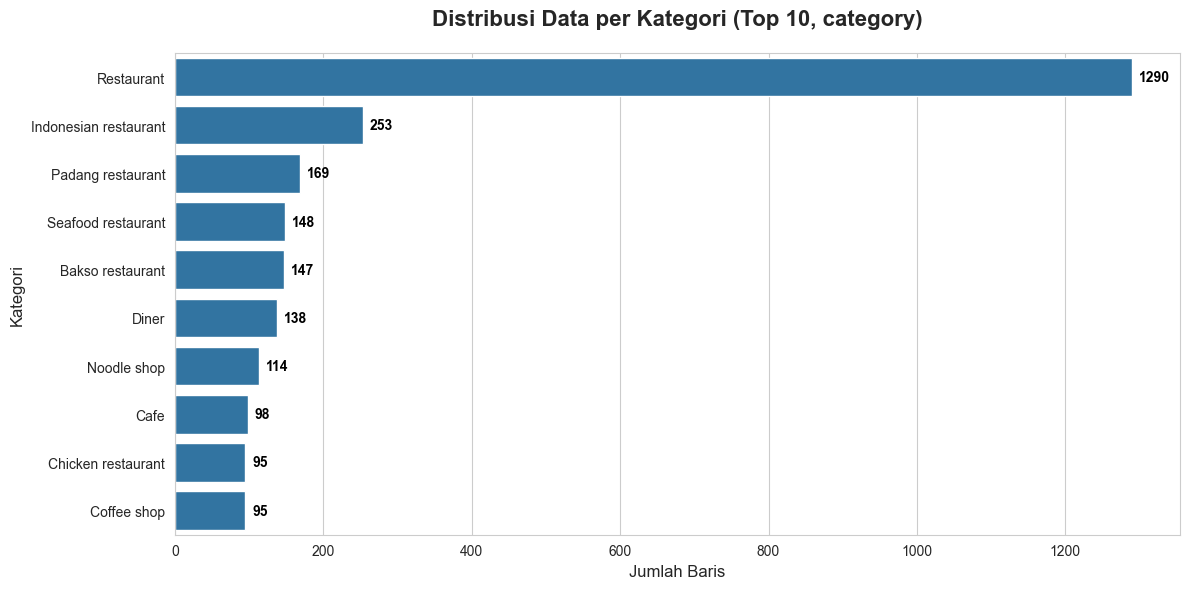

In [6]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

frames = []
load_report = []

def _normalize_text(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.strip()
    cleaned = cleaned.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "none": pd.NA})
    return cleaned

def preprocess_table(df_temp: pd.DataFrame, source_cat: str, filename: str, table: str) -> pd.DataFrame:
    df_temp = df_temp.rename(columns=COLUMN_MAPPING)

    df_temp["source_category"] = source_cat
    df_temp["source_file"] = filename
    df_temp["source_table"] = table

    if "category" not in df_temp.columns:
        df_temp["category"] = pd.NA

    for col in ["name", "category"]:
        if col in df_temp.columns:
            df_temp[col] = _normalize_text(df_temp[col])

    for col in ["latitude", "longitude", "rating", "reviews", "review"]:
        if col in df_temp.columns:
            df_temp[col] = pd.to_numeric(df_temp[col], errors="coerce")

    required_cols = ["latitude", "longitude", "name", "category"]
    required_present = [c for c in required_cols if c in df_temp.columns]
    rows_before = len(df_temp)
    df_temp = df_temp.dropna(subset=required_present)
    rows_after = len(df_temp)

    return df_temp, rows_before, rows_after

print("Memulai proses penggabungan data (single DB)...")

# --- PROSES PEMBACAAN DATA ---
for db_path in db_files:
    filename = os.path.basename(db_path)
    file_key = filename.replace(".db", "")

    # Ambil kategori (Contoh logika: mapping atau fallback)
    source_cat = CATEGORY_MAPPING.get(file_key, "Unknown")

    try:
        conn = sqlite3.connect(db_path)
        tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()
        user_tables = [t for t in tables if t not in SQLITE_INTERNAL_TABLES]

        for table in user_tables:
            df_temp = pd.read_sql(f"SELECT * FROM [{table}]", conn)
            df_temp, rows_before, rows_after = preprocess_table(
                df_temp, source_cat, filename, table
            )
            frames.append(df_temp)
            load_report.append({
                "File Name": filename,
                "Category": source_cat,
                "Table": table,
                "Rows Raw": rows_before,
                "Rows Kept": rows_after,
                "Rows Dropped": rows_before - rows_after,
            })
        conn.close()
    except Exception as e:
        print(f"Gagal memproses {filename}: {e}")

if not frames:
    raise ValueError("Tidak ada data yang berhasil dimuat dari DB target.")

# Gabungkan Data
df_raw = pd.concat(frames, ignore_index=True)
df_report = pd.DataFrame(load_report)

# --- VISUALISASI 1: TABEL LAPORAN (Styled) ---
print("\n📊 LAPORAN AUDIT DATA:")
total_raw = int(df_report["Rows Raw"].sum()) if not df_report.empty else 0
total_kept = int(df_report["Rows Kept"].sum()) if not df_report.empty else 0
actual_rows = len(df_raw)
is_consistent = actual_rows == total_kept

display(df_report)

# --- VISUALISASI 2: STATUS INTEGRITAS (HTML Box) ---
status_text = "JUMLAH BARIS KONSISTEN" if is_consistent else f"⚠️ SELISIH DATA: {abs(actual_rows - total_kept)} baris!"
print(f"\n{status_text}")
print(f"{'-'*60}")
print(f"Total Baris di DataFrame : {actual_rows:,}")
print(f"Total Baris Raw (Sum)    : {total_raw:,}")
print(f"Total Baris Kept (Sum)   : {total_kept:,}")
print(f"{'-'*60}")

# --- VISUALISASI 3: GRAFIK DISTRIBUSI (Matplotlib/Seaborn) ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

dist_col = CAT_COL if CAT_COL in df_raw.columns else "source_category"
dist_full = df_raw[dist_col].value_counts().reset_index()
dist_full.columns = ['Kategori', 'Jumlah']

print("\nTabel distribusi kategori (Top 10):")
display(dist_full.head(10))

run_dir = os.path.join("content", "runs", TARGET_DB_KEY if "TARGET_DB_KEY" in globals() else "unknown_run")
data_dir = os.path.join(run_dir, "data")
os.makedirs(data_dir, exist_ok=True)
if len(dist_full) > 10:
    dist_json_path = os.path.join(data_dir, "category_distribution.json")
    dist_full.to_json(dist_json_path, orient="records", force_ascii=True, indent=2)
    print(f"Distribusi penuh disimpan: {dist_json_path}")

dist_top = dist_full.head(10)
ax = sns.barplot(x='Jumlah', y='Kategori', data=dist_top)
for i in ax.containers:
    ax.bar_label(i, fmt='%d', padding=5, fontweight='bold', color='black')

plt.title(f'Distribusi Data per Kategori (Top 10, {dist_col})', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jumlah Baris', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.tight_layout()
plt.show()

## 2.5 Verifikasi hasil gabungan

Ringkas: cek kolom wajib, null, dan konsistensi data gabungan.

In [7]:
# Sebelum masuk ke Validation Gate (Tahap 3), pastikan:
# 1. Kolom wajib sudah ada
# 2. Tidak ada kategori yang hilang
# 3. Distribusi data masuk akal (tidak ada file yang 0 baris)

from IPython.display import display, HTML
import pandas as pd

print("Verifikasi DataFrame gabungan:\n")

# --- 1. VERIFIKASI KOLOM WAJIB ---
print("🔍 1. Verifikasi Kolom Wajib")
missing_required = [c for c in REQUIRED_COLS_FINAL if c not in df_raw.columns]

if missing_required:
    status_html = f"<span style='color:red;'><b>⚠ BELUM LENGKAP:</b> {missing_required}</span>"
else:
    status_html = "<span style='color:green;'><b>✓ SEMUA KOLOM TERSEDIA</b></span>"

display(HTML(f"Status: {status_html}<br><small>Target: {REQUIRED_COLS_FINAL}</small>"))
print("-" * 30)

# --- 2. SAMPLE PER KATEGORI (Consolidated Table) ---
print("\n🔍 2. Sampel Data per Kategori")
group_col = CAT_COL if CAT_COL in df_raw.columns else "source_category"
cols_to_show = [c for c in ['name', LAT_COL, LON_COL, CAT_COL, 'source_category', 'source_file', 'source_table'] if c in df_raw.columns]
df_sample = df_raw.groupby(group_col).head(2)[cols_to_show]
display(df_sample.reset_index(drop=True))
print("-" * 30)

# --- 3. NULL COUNT ---
print("\n🔍 3. Analisis Missing Values")
crit_cols = [c for c in REQUIRED_COLS_FINAL if c in df_raw.columns]
null_report = df_raw[crit_cols].isnull().sum().reset_index()
null_report.columns = ['Kolom', 'Jumlah Null']
null_report['Persentase'] = (null_report['Jumlah Null'] / len(df_raw) * 100).map("{:.2f}%".format)
display(null_report)

print("-" * 30)

# --- 4. RINGKASAN METADATA ---
print("\n🔍 4. Ringkasan Teknis")
info_data = {
    "Metrik": ["Shape (Baris, Kolom)", "Memory Usage", "Status Akhir"],
    "Nilai": [
        f"{df_raw.shape[0]:,} baris, {df_raw.shape[1]} kolom",
        f"{df_raw.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB",
        "SIAP VALIDASI" if not missing_required else "PERLU REVISI"
    ],
}
display(pd.DataFrame(info_data))

print("\n" + "="*40)
print("Siap masuk Tahap 3 — Validation Gate")
print("="*40)


Verifikasi DataFrame gabungan:

🔍 1. Verifikasi Kolom Wajib


------------------------------

🔍 2. Sampel Data per Kategori


,name,latitude,longitude,category,source_category,source_file,source_table
0,Pacific food court,1.151015,104.000602,Restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1,Berjaya Masakan Padang,1.154278,104.005409,Padang restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
2,Warung Kopi HARUM,1.150087,104.011475,Noodle shop,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
3,Toko Barokah,1.183346,104.013658,Grocery store,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
4,Multi Bintang Indonesia,1.167812,104.010056,Grocery delivery service,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
...,...,...,...,...,...,...,...
340,Rumah Singgah Coffee Roasters,1.108963,103.984404,Coffee roasters,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
341,Nasi Uduk 86 Tiban III,1.110397,103.965568,Nasi uduk restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
342,Ayam Betutu Bu Wayan Batam,1.110693,103.979853,Balinese restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
343,Gethuk Jadoel Tiban,1.117315,103.977304,Dessert shop,F&B,Indonesia.Batam.Kuliner.202406162232.db,places


------------------------------

🔍 3. Analisis Missing Values


,Kolom,Jumlah Null,Persentase
0,latitude,0,0.00%
1,longitude,0,0.00%
2,name,0,0.00%
3,category,0,0.00%


------------------------------

🔍 4. Ringkasan Teknis


,Metrik,Nilai
0,"Shape (Baris, Kolom)","4,206 baris, 17 kolom"
1,Memory Usage,2.91 MB
2,Status Akhir,SIAP VALIDASI



Siap masuk Tahap 3 — Validation Gate


In [8]:
# Mengambil hanya baris yang memiliki minimal satu kolom null pada kolom kritis
df_problematic = df_raw[df_raw[crit_cols].isnull().any(axis=1)]

print(f"Ditemukan {len(df_problematic)} baris bermasalah.")
print("Berikut adalah daftar file dan tabel asalnya:")

cols_meta = [c for c in ['source_file', 'source_table', 'source_category', CAT_COL] if c in df_problematic.columns]
if cols_meta:
    display(df_problematic[cols_meta].value_counts().reset_index(name='null_count'))

# Tampilkan 10 sampel data yang kosong tersebut
display(df_problematic.head(10))

Ditemukan 0 baris bermasalah.
Berikut adalah daftar file dan tabel asalnya:


,source_file,source_table,source_category,category,null_count


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster,source_category,source_file,source_table


In [9]:
# Menghapus baris yang nama atau koordinatnya kosong
required_clean = [c for c in ['name', 'latitude', 'longitude', CAT_COL] if c in df_raw.columns]
df_raw_clean = df_raw.dropna(subset=required_clean).copy()

print(f"Baris sebelum dibersihkan: {len(df_raw):,}")
print(f"Baris setelah dibersihkan: {len(df_raw_clean):,}")
print(f"Data dibuang: {len(df_raw) - len(df_raw_clean)} baris")

# Gunakan df_raw_clean untuk membersihkan data
df_raw = df_raw_clean

Baris sebelum dibersihkan: 4,206
Baris setelah dibersihkan: 4,206
Data dibuang: 0 baris


---
# Tahap 3 — Konfigurasi & Konstanta

Semua parameter yang mungkin perlu diubah dikumpulkan di satu tempat agar mudah di-tuning tanpa harus mencari di tengah kode.

**Parameter DBSCAN yang perlu diperhatikan:**
- `EPS_METER` → radius pencarian tetangga dalam meter. Nilai default 150m berarti "titik A dan B dianggap tetangga jika jaraknya ≤ 150 meter". Terlalu kecil = terlalu banyak noise, terlalu besar = semua jadi satu cluster.
- `MIN_SAMPLES` → jumlah minimum titik dalam radius EPS untuk membentuk cluster. Nilai 5 berarti "minimal ada 5 usaha dalam radius 150m untuk membentuk zona konsentrasi".

In [10]:
import os
import numpy as np

# ── Path ──────────────────────────────────────────────────────────────
DB_FOLDER = "content/data/raw"
RUNS_DIR  = "content/runs"

if "TARGET_DB_FILE" not in globals() or not TARGET_DB_FILE:
    raise ValueError("TARGET_DB_FILE belum diisi di Tahap 2.1")

TARGET_DB_KEY = TARGET_DB_KEY if "TARGET_DB_KEY" in globals() else os.path.splitext(TARGET_DB_FILE)[0]
RUN_DIR = os.path.join(RUNS_DIR, TARGET_DB_KEY)
OUTPUT_DIR = os.path.join(RUN_DIR, "data")
REPORT_DIR = os.path.join(RUN_DIR, "reports")
MODEL_DIR = os.path.join(RUN_DIR, "models")

FEATURE_STORE_PATH = os.path.join(OUTPUT_DIR, "feature_store.csv")
METADATA_PATH = os.path.join(MODEL_DIR, "clustering_metadata.json")

# ── Batas wilayah Batam (Validation Gate) ────────────────────────────
# Tidak berubah — tetap digunakan untuk filter koordinat
BATAM_LAT_MIN =  1.00
BATAM_LAT_MAX =  1.30
BATAM_LON_MIN = 103.60
BATAM_LON_MAX = 104.20

# ── Parameter DBSCAN ─────────────────────────────────────────────────
# Tuning lebih lanjut dilakukan di Tahap 6.
EPS_METER   = 500   # radius pencarian tetangga dalam meter
MIN_SAMPLES = 10     # minimum titik untuk membentuk core point

# ── Sistem koordinat ──────────────────────────────────────────────────
CRS_WGS84  = "EPSG:4326"   # input  → derajat (lat/lon dari Google Maps)
CRS_UTM48N = "EPSG:32648"  # output → meter   (akurat untuk wilayah Batam)

# ── Radius analisis kompetitor ────────────────────────────────────────
RADIUS_500M = 500
RADIUS_1KM  = 1000

# ── Nama kolom standar (hasil mapping dari Cell 4) ────────────────────
LAT_COL = "latitude"
LON_COL = "longitude"
CAT_COL = "category"   # gunakan kategori dari data sumber

# ── Kolom wajib yang harus ada di df_raw ─────────────────────────────
REQUIRED_COLS = [LAT_COL, LON_COL, "name", CAT_COL]

# ── Seed reproduktibilitas ────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Buat direktori output ─────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Tampilkan ringkasan konfigurasi ───────────────────────────────────
from IPython.display import display
import pandas as pd

df_config = pd.DataFrame([
    {"parameter": "Target DB",         "nilai": TARGET_DB_FILE},
    {"parameter": "Run Dir",           "nilai": RUN_DIR},
    {"parameter": "Data Dir",          "nilai": OUTPUT_DIR},
    {"parameter": "Report Dir",        "nilai": REPORT_DIR},
    {"parameter": "Model Dir",         "nilai": MODEL_DIR},
    {"parameter": "Feature Store",     "nilai": FEATURE_STORE_PATH},
    {"parameter": "Metadata Path",     "nilai": METADATA_PATH},
    {"parameter": "Lat Col",           "nilai": LAT_COL},
    {"parameter": "Lon Col",           "nilai": LON_COL},
    {"parameter": "Category Col",      "nilai": CAT_COL},
    {"parameter": "Batam Lat Range",   "nilai": f"{BATAM_LAT_MIN} – {BATAM_LAT_MAX}"},
    {"parameter": "Batam Lon Range",   "nilai": f"{BATAM_LON_MIN} – {BATAM_LON_MAX}"},
    {"parameter": "EPS",               "nilai": f"{EPS_METER} meter"},
    {"parameter": "Min Samples",       "nilai": str(MIN_SAMPLES)},
    {"parameter": "CRS Input",         "nilai": CRS_WGS84},
    {"parameter": "CRS Output",        "nilai": CRS_UTM48N},
    {"parameter": "Radius 1",          "nilai": f"{RADIUS_500M} meter"},
    {"parameter": "Radius 2",          "nilai": f"{RADIUS_1KM} meter"},
    {"parameter": "Random Seed",       "nilai": str(RANDOM_SEED)},
])

display(df_config)

,parameter,nilai
0,Target DB,Indonesia.Batam.Kuliner.202406162232.db
1,Run Dir,content/runs\Indonesia.Batam.Kuliner.202406162232
2,Data Dir,content/runs\Indonesia.Batam.Kuliner.202406162...
3,Report Dir,content/runs\Indonesia.Batam.Kuliner.202406162...
4,Model Dir,content/runs\Indonesia.Batam.Kuliner.202406162...
5,Feature Store,content/runs\Indonesia.Batam.Kuliner.202406162...
6,Metadata Path,content/runs\Indonesia.Batam.Kuliner.202406162...
7,Lat Col,latitude
8,Lon Col,longitude
9,Category Col,category


---
# Tahap 4 — Ingestion & Validation Gate

**Apa yang dilakukan di sini:**  
1. Baca data dari SQLite ke DataFrame
2. Periksa skema dan tipe data
3. Jalankan Validation Gate — filter data yang tidak valid
4. Hasilkan Data Quality Report

**Mengapa Validation Gate penting sebelum clustering?**  
DBSCAN sangat sensitif terhadap outlier koordinat. Satu titik dengan lat/lon salah (misalnya `0.0, 0.0`) akan membuat satu cluster tersendiri yang tidak bermakna dan merusak hasil seluruh clustering.

Data berhasil dimuat: 4,206 baris × 17 kolom

Ringkasan tipe data:


,kolom,tipe_data
0,id,int64
1,name,str
2,rating,float64
3,review,int64
4,price_level,int64
5,category,str
6,services,str
7,address,str
8,open_hours,str
9,phone,str



Missing values pada kolom wajib:


,kolom,jumlah_null,persentase
0,latitude,0,0.0
1,longitude,0,0.0
2,name,0,0.0
3,category,0,0.0


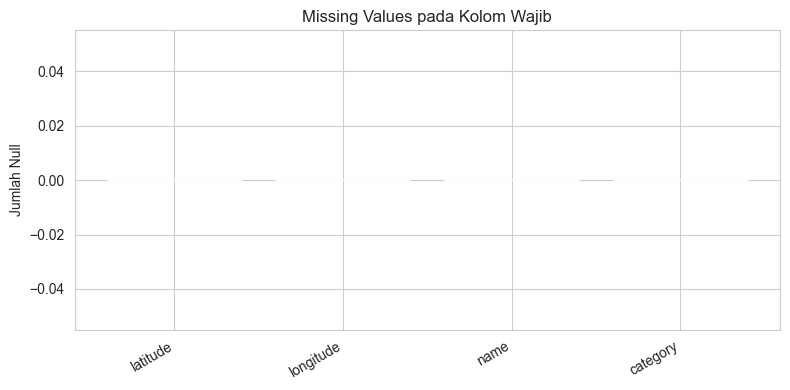


Sampel 10 baris pertama:


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster,source_category,source_file,source_table
0,96,Pacific food court,4.4,233,2,Restaurant,"['Dine-in', 'Takeaway']","5222+C65, Jodoh River, Batu Ampar, Batam City,...",[],,1.151015,104.000602,https://www.google.com/maps/place/Pacific+food...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
1,193,Berjaya Masakan Padang,4.0,3,0,Padang restaurant,"['Dine-in', 'Takeaway']","5234+P57, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '09:00 – 21:00' }, { ...",,1.154278,104.005409,https://www.google.com/maps/place/Berjaya+Masa...,0.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
2,211,Warung Kopi HARUM,4.4,303,0,Noodle shop,"['Dine-in', 'Takeaway']","5226+2HQ, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '06:00 – 14:00' }, { ...",,1.150087,104.011475,https://www.google.com/maps/place/Warung+Kopi+...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
3,230,Toko Barokah,4.0,5,0,Grocery store,['In-store shopping'],"52M7+8FM, Batu Merah, Batu Ampar, Batam City, ...","[{ day: 'Sunday', hours: '07:00 – 21:00' }, { ...",,1.183346,104.013658,https://www.google.com/maps/place/Toko+Barokah...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
4,240,Multi Bintang Indonesia,4.5,2,0,Grocery delivery service,[],"5296+42F, Batu Merah, Batu Ampar, Batam City, ...",[],,1.167812,104.010056,https://www.google.com/maps/place/Multi+Bintan...,3.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
5,257,Ampera nasi padang Ombak piaman,0.0,0,0,Padang restaurant,"['Dine-in', 'Takeaway']","5243+3P8, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '08:00 – 21:30' }, { ...",,1.155156,104.004325,https://www.google.com/maps/place/Ampera+nasi+...,0.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
6,282,Pak Bas Kue & Kripic,4.0,2,0,Food products supplier,[],"52P5+VP2, Batu Merah, Batu Ampar, Batam City, ...","[{ day: 'Sunday', hours: '06:00 – 22:00' }, { ...",+62 812-7742-6621,1.187141,104.009264,https://www.google.com/maps/place/Pak+Bas+Kue+...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
7,292,Seblak Teh Senny - Bengkong,3.4,28,0,Buffet restaurant,"['Dine-in', 'Takeaway', 'Delivery']","Pertokoan Jl. Ruko Golden City Blok F No. 6, B...","[{ day: 'Sunday', hours: '03:00 – 23:00' }, { ...",+62 821-7132-0270,1.165564,104.039307,https://www.google.com/maps/place/Seblak+Teh+S...,2.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
8,299,SOTO LAMONGAN CAK ALI,4.4,13,0,Soto ayam restaurant,"['Dine-in', 'Takeaway']","Komplek Maritim Square Jodoh, Blk. I No.21, RT...","[{ day: 'Sunday', hours: '11:00 – 21:00' }, { ...",,1.153548,104.005480,https://www.google.com/maps/place/SOTO+LAMONGA...,-1.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places
9,303,Bina Nusa Mandiri PT,0.0,0,0,Caterer,[],"Bukit Senyum, Batu Ampar, Komplek Malindo Cipt...",[],,1.168829,104.011295,https://www.google.com/maps/place/Bina+Nusa+Ma...,5.0,F&B,Indonesia.Batam.Kuliner.202406162232.db,places


In [11]:
# ── 3.1 Load data ─────────────────────────────────────────────────────
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

print(f"Data berhasil dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")

df_dtypes = df_raw.dtypes.reset_index()
df_dtypes.columns = ["kolom", "tipe_data"]
print("\nRingkasan tipe data:")
display(df_dtypes)

required_cols_view = REQUIRED_COLS_FINAL if "REQUIRED_COLS_FINAL" in globals() else REQUIRED_COLS
missing_required = [c for c in required_cols_view if c not in df_raw.columns]
if missing_required:
    print(f"⚠ Kolom wajib hilang: {missing_required}")

null_counts = df_raw[required_cols_view].isnull().sum().reset_index()
null_counts.columns = ["kolom", "jumlah_null"]
null_counts["persentase"] = (null_counts["jumlah_null"] / len(df_raw) * 100).round(2)
print("\nMissing values pada kolom wajib:")
display(null_counts)

plt.figure(figsize=(8, 4))
plt.bar(null_counts["kolom"], null_counts["jumlah_null"], color="#dc3545")
plt.title("Missing Values pada Kolom Wajib")
plt.ylabel("Jumlah Null")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nSampel 10 baris pertama:")
display(df_raw.head(10))

✓ Konversi tipe data selesai

Validation Gate — Detail per Aturan


,aturan,kolom,dibuang,sisa,dibuang_%
0,1 — Null pada kolom wajib,"latitude, longitude, name, category",0,4206,0.0
1,2 — Duplikat dalam file yang sama,"name, latitude, longitude, source_file",0,4206,0.0
2,3 — Duplikat lintas file (cross-file),"name, latitude, longitude",0,4206,0.0
3,4 — Rating di luar rentang 0–5,rating,0,4206,0.0



Data Quality Report


,keterangan,nilai
0,Total data masuk,4206
1,Total ditolak,0
2,Total valid,4206
3,Tingkat validitas,100.0
4,Rejection log,content/runs\Indonesia.Batam.Kuliner.202406162...



Distribusi Data Valid per Kategori (Top 10)


,category,valid_rows
0,Restaurant,1290
1,Indonesian restaurant,253
2,Padang restaurant,169
3,Seafood restaurant,148
4,Bakso restaurant,147
5,Diner,138
6,Noodle shop,114
7,Cafe,98
8,Chicken restaurant,95
9,Coffee shop,95


Distribusi penuh disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\data\category_distribution_valid.json


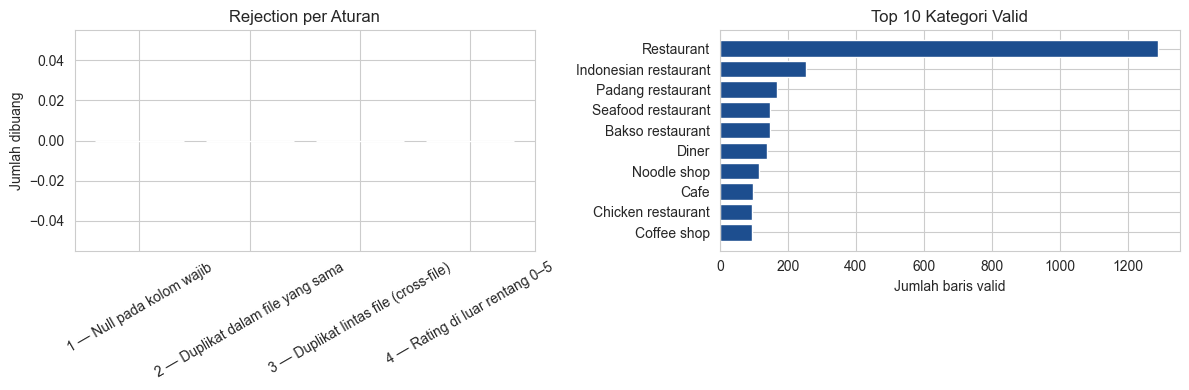

In [12]:
# ── 3.3 Validation Gate ───────────────────────────────────────────────
import os
import matplotlib.pyplot as plt
from IPython.display import display

df            = df_raw.copy()
total_raw     = len(df)
rejection_log = []
validation_summary = []

# ─────────────────────────────────────────────────────────────────────
# PRE-STEP: Konversi tipe data kolom numerik
# ─────────────────────────────────────────────────────────────────────
# Kolom lat/lon/rating bisa tersimpan sebagai string di SQLite.
# Konversi ke numeric dulu — nilai yang tidak bisa dikonversi
# akan menjadi NaN dan tertangkap oleh Aturan 1 (null check).

numeric_cols = [LAT_COL, LON_COL]
if 'rating' in df.columns:
    numeric_cols.append('rating')

for col in numeric_cols:
    if col in df.columns:
        before = df[col].dtype
        df[col] = pd.to_numeric(df[col], errors='coerce')
        after   = df[col].dtype
        if str(before) != str(after):
            print(f"  konversi kolom '{col}': {before} → {after}")

print("✓ Konversi tipe data selesai\n")

# ─────────────────────────────────────────────────────────────────────
# Aturan 1: Kolom wajib tidak boleh null
# ─────────────────────────────────────────────────────────────────────
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(
        f"Kolom wajib tidak ditemukan di df_raw: {missing_cols}\n"
        f"Periksa COLUMN_MAPPING di Cell 4 atau REQUIRED_COLS di Tahap 2."
    )

mask_null = df[REQUIRED_COLS].isnull().any(axis=1)
null_rows = df[mask_null].copy()
null_rows['rejection_reason'] = 'null_required_column'
rejection_log.append(null_rows)
df = df[~mask_null]

validation_summary.append({
    "aturan"  : "1 — Null pada kolom wajib",
    "kolom"   : ", ".join(REQUIRED_COLS),
    "dibuang" : int(mask_null.sum()),
    "sisa"    : len(df),
})

# ─────────────────────────────────────────────────────────────────────
# Aturan 2: Duplikat dalam file yang sama
# ─────────────────────────────────────────────────────────────────────
df['_lat_r'] = df[LAT_COL].round(5)
df['_lon_r'] = df[LON_COL].round(5)

mask_dup = df.duplicated(
    subset=['name', '_lat_r', '_lon_r', 'source_file'],
    keep='first'
 )
dup_rows = df[mask_dup].copy()
dup_rows['rejection_reason'] = 'duplicate_within_file'
rejection_log.append(dup_rows)
df = df[~mask_dup]

validation_summary.append({
    "aturan"  : "2 — Duplikat dalam file yang sama",
    "kolom"   : "name, latitude, longitude, source_file",
    "dibuang" : int(mask_dup.sum()),
    "sisa"    : len(df),
})

# ─────────────────────────────────────────────────────────────────────
# Aturan 3: Duplikat lintas file (cross-file duplicate)
# ─────────────────────────────────────────────────────────────────────
mask_cross = df.duplicated(
    subset=['name', '_lat_r', '_lon_r'],
    keep='first'
 )
cross_rows = df[mask_cross].copy()
cross_rows['rejection_reason'] = 'duplicate_cross_file'
rejection_log.append(cross_rows)
df = df[~mask_cross]

validation_summary.append({
    "aturan"  : "3 — Duplikat lintas file (cross-file)",
    "kolom"   : "name, latitude, longitude",
    "dibuang" : int(mask_cross.sum()),
    "sisa"    : len(df),
})

df = df.drop(columns=['_lat_r', '_lon_r'])

# ─────────────────────────────────────────────────────────────────────
# Aturan 4: Rating harus dalam rentang wajar (0.0 – 5.0)
# ─────────────────────────────────────────────────────────────────────
if 'rating' in df.columns:
    mask_rating = (
        df['rating'].notna() &
        ~df['rating'].between(0.0, 5.0, inclusive='both')
    )
    rat_rows = df[mask_rating].copy()
    rat_rows['rejection_reason'] = 'rating_out_of_range'
    rejection_log.append(rat_rows)
    df = df[~mask_rating]

    validation_summary.append({
        "aturan"  : "4 — Rating di luar rentang 0–5",
        "kolom"   : "rating",
        "dibuang" : int(mask_rating.sum()),
        "sisa"    : len(df),
    })

# ─────────────────────────────────────────────────────────────────────
# Simpan rejection log
# ─────────────────────────────────────────────────────────────────────
valid_logs     = [r for r in rejection_log if len(r) > 0]
total_rejected = total_raw - len(df)

if valid_logs:
    df_rejected = pd.concat(valid_logs, ignore_index=True)
    df_rejected.to_csv(f"{OUTPUT_DIR}/rejected_rows.csv", index=False)
else:
    df_rejected = pd.DataFrame()

df = df.reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────
# Output terstruktur
# ─────────────────────────────────────────────────────────────────────
# Tabel 1: detail per aturan
df_val = pd.DataFrame(validation_summary)
df_val["dibuang_%"] = (df_val["dibuang"] / total_raw * 100).round(2)
print("Validation Gate — Detail per Aturan")
display(df_val)

# Tabel 2: ringkasan akhir
df_summary = pd.DataFrame([
    {"keterangan": "Total data masuk",  "nilai": total_raw},
    {"keterangan": "Total ditolak",     "nilai": total_rejected},
    {"keterangan": "Total valid",       "nilai": len(df)},
    {"keterangan": "Tingkat validitas", "nilai": round(len(df)/total_raw*100, 1)},
    {"keterangan": "Rejection log",     "nilai": f"{OUTPUT_DIR}/rejected_rows.csv"},
])
print("\nData Quality Report")
display(df_summary)

# Tabel 3: distribusi valid per kategori
df_cat_valid = (
    df.groupby(CAT_COL)
    .size()
    .reset_index(name="valid_rows")
    .sort_values("valid_rows", ascending=False)
    .reset_index(drop=True)
 )
print("\nDistribusi Data Valid per Kategori (Top 10)")
display(df_cat_valid.head(10))
if len(df_cat_valid) > 10:
    dist_valid_path = os.path.join(OUTPUT_DIR, "category_distribution_valid.json")
    df_cat_valid.to_json(dist_valid_path, orient="records", force_ascii=True, indent=2)
    print(f"Distribusi penuh disimpan: {dist_valid_path}")

# ── Visualisasi ringkas ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar: jumlah dibuang per aturan
axes[0].bar(df_val["aturan"], df_val["dibuang"], color="#D85A30")
axes[0].set_title("Rejection per Aturan")
axes[0].set_ylabel("Jumlah dibuang")
axes[0].tick_params(axis='x', rotation=30)

# Bar: top kategori valid
top_n = min(10, len(df_cat_valid))
axes[1].barh(df_cat_valid[CAT_COL].head(top_n), df_cat_valid["valid_rows"].head(top_n), color="#1D4E8F")
axes[1].set_title(f"Top {top_n} Kategori Valid")
axes[1].invert_yaxis()
axes[1].set_xlabel("Jumlah baris valid")

plt.tight_layout()
plt.show()

if not df_rejected.empty:
    reject_reason = df_rejected["rejection_reason"].value_counts().reset_index()
    reject_reason.columns = ["rejection_reason", "count"]
    print("\nRejection Reason Summary")
    display(reject_reason)

---
# Tahap 5 — Preprocessing & Konversi Koordinat

**Ini adalah langkah yang paling sering dilewatkan dan paling kritis.**

DBSCAN di scikit-learn menerima array angka sebagai input. Jika kita langsung masukkan `latitude` dan `longitude` (dalam derajat), maka:
- `eps=0.001` derajat ≈ 111 meter di garis khatulistiwa
- Tapi perbedaan jarak 1 derajat longitude di Batam (lat ~1°N) berbeda dengan di Jakarta (lat ~6°S)

**Solusi:** Konversi ke koordinat UTM Zone 48N (EPSG:32648) yang satuannya **meter** — sehingga `eps=150` benar-benar berarti 150 meter di semua arah, tanpa distorsi.

Alternatif lain adalah menggunakan `metric='haversine'` dengan input radian, tapi pendekatan UTM lebih intuitif untuk tuning parameter.

Ringkasan rentang koordinat:


,metrik,min,max
0,latitude,-8.020151,5.582374e+00
1,longitude,95.283657,1.178888e+02
2,x_utm,-581270.753785,1.945182e+06
3,y_utm,-894588.626756,6.258946e+05



Sampel 10 baris pertama (WGS84 → UTM):


,latitude,longitude,x_utm,y_utm
0,1.151015,104.000602,388808.675066,127241.394226
1,1.154278,104.005409,389343.640633,127601.867659
2,1.150087,104.011475,390018.406080,127138.429168
3,1.183346,104.013658,390262.662658,130815.027225
4,1.167812,104.010056,389861.199647,129097.909087
5,1.155156,104.004325,389223.025219,127699.025668
6,1.187141,104.009264,389773.856398,131234.672603
7,1.165564,104.039307,393115.866044,128848.227864
8,1.153548,104.005480,389351.545948,127521.220667
9,1.168829,104.011295,389999.167856,129210.231633


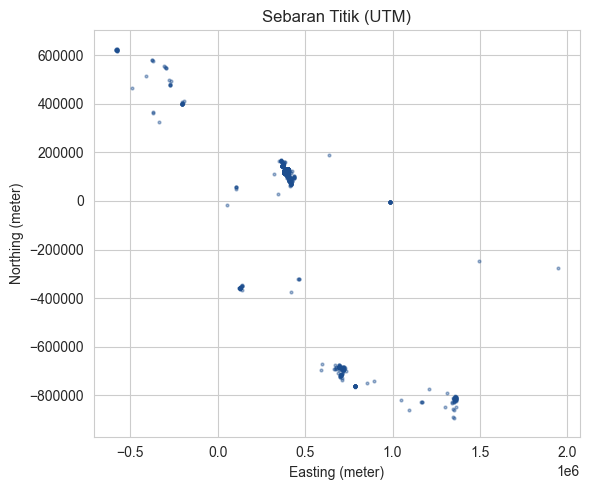

In [13]:
# ── 4.1 Konversi koordinat WGS84 → UTM Zone 48N ──────────────────────
#
# Mengapa UTM Zone 48N?
# Batam berada di zona UTM 48N (lon 102°E – 108°E, belahan utara).
# Koordinat UTM dalam satuan meter, sehingga EPS_METER langsung berarti meter.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

transformer = Transformer.from_crs(CRS_WGS84, CRS_UTM48N, always_xy=True)

# Konversi: lon dulu, baru lat (urutan 'always_xy': x=lon, y=lat)
df['x_utm'], df['y_utm'] = transformer.transform(
    df[LON_COL].values,
    df[LAT_COL].values
)

df_coords = df[[LAT_COL, LON_COL, 'x_utm', 'y_utm']].copy()
summary_ranges = pd.DataFrame([
    {"metrik": "latitude",  "min": df_coords[LAT_COL].min(), "max": df_coords[LAT_COL].max()},
    {"metrik": "longitude", "min": df_coords[LON_COL].min(), "max": df_coords[LON_COL].max()},
    {"metrik": "x_utm",     "min": df_coords['x_utm'].min(),  "max": df_coords['x_utm'].max()},
    {"metrik": "y_utm",     "min": df_coords['y_utm'].min(),  "max": df_coords['y_utm'].max()},
])

print("Ringkasan rentang koordinat:")
display(summary_ranges)

print("\nSampel 10 baris pertama (WGS84 → UTM):")
display(df_coords.head(10))

plt.figure(figsize=(6, 5))
plt.scatter(df['x_utm'], df['y_utm'], s=4, alpha=0.4, color="#1D4E8F")
plt.title("Sebaran Titik (UTM)")
plt.xlabel("Easting (meter)")
plt.ylabel("Northing (meter)")
plt.tight_layout()
plt.show()

Rating — median: 4.40, null diisi median

Ringkasan statistik fitur atribut:


,rating,review_log
count,4206.00,4206.00
mean,3.84,2.51
std,1.63,2.10
min,0.00,0.00
25%,4.00,0.69
50%,4.40,1.95
75%,4.90,3.84
max,5.00,9.82



Top 10 kategori:


,category,count
0,restaurant,1290
1,indonesian restaurant,253
2,padang restaurant,169
3,seafood restaurant,148
4,bakso restaurant,147
5,diner,138
6,noodle shop,114
7,cafe,98
8,chicken restaurant,95
9,coffee shop,95


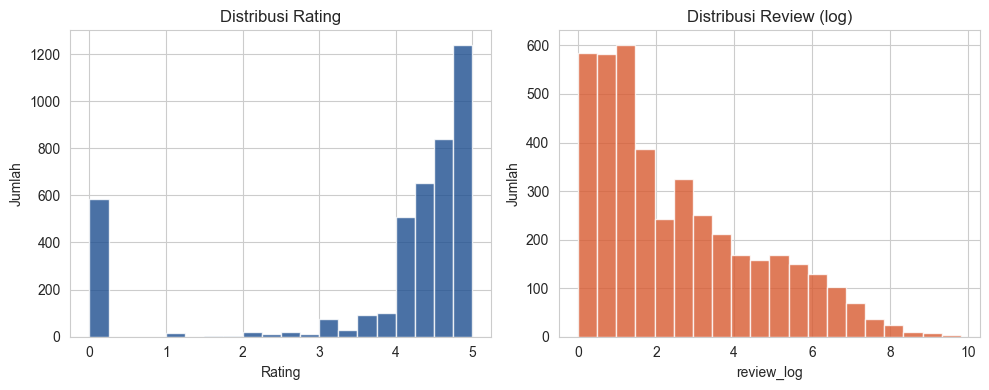


✓ Preprocessing selesai. Shape: (4206, 20)


In [14]:
# ── 4.2 Persiapan fitur atribut tambahan ─────────────────────────────
#
# Selain koordinat, kita siapkan fitur-fitur lain yang akan digunakan
# oleh Random Forest nanti. Di sini kita buat versi awalnya.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# --- review_log: transformasi log untuk mengurangi skewness ---
# Usaha dengan 10 review vs 10.000 review tidak perlu dibedakan sebesar itu
if 'reviews' in df.columns:
    df['review_log'] = np.log1p(df['reviews'])  # log(1 + x) agar x=0 tidak error
elif 'review' in df.columns:
    df['review_log'] = np.log1p(df['review'])
else:
    df['review_log'] = 0.0
    print("⚠ Kolom review tidak ditemukan, review_log diset 0")

# --- rating: isi nilai null dengan median ---
if 'rating' in df.columns:
    median_rating = df['rating'].median()
    df['rating'] = df['rating'].fillna(median_rating)
    print(f"Rating — median: {median_rating:.2f}, null diisi median")

# --- Normalisasi kategori: lowercase + strip whitespace ---
cat_col = CAT_COL if CAT_COL in df.columns else ("category" if "category" in df.columns else None)
if cat_col:
    df[cat_col] = df[cat_col].astype(str).str.lower().str.strip()
else:
    print("⚠ Kolom kategori tidak ditemukan untuk normalisasi")

summary_cols = [c for c in ['rating', 'review_log'] if c in df.columns]
if summary_cols:
    print("\nRingkasan statistik fitur atribut:")
    display(df[summary_cols].describe().round(2))

if cat_col:
    cat_counts = df[cat_col].value_counts().head(10).reset_index()
    cat_counts.columns = [cat_col, 'count']
    print("\nTop 10 kategori:")
    display(cat_counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if 'rating' in df.columns:
    axes[0].hist(df['rating'].dropna(), bins=20, color="#1D4E8F", alpha=0.8)
    axes[0].set_title("Distribusi Rating")
    axes[0].set_xlabel("Rating")
    axes[0].set_ylabel("Jumlah")
else:
    axes[0].axis("off")
    axes[0].text(0.5, 0.5, "Rating tidak tersedia", ha="center", va="center")

if 'review_log' in df.columns:
    axes[1].hist(df['review_log'].dropna(), bins=20, color="#D85A30", alpha=0.8)
    axes[1].set_title("Distribusi Review (log)")
    axes[1].set_xlabel("review_log")
    axes[1].set_ylabel("Jumlah")
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "Review tidak tersedia", ha="center", va="center")

plt.tight_layout()
plt.show()

print(f"\n✓ Preprocessing selesai. Shape: {df.shape}")

---
# Tahap 6 — DBSCAN Clustering

### Cara Kerja DBSCAN

DBSCAN mengklasifikasikan setiap titik menjadi salah satu dari tiga jenis:

| Jenis Titik | Kondisi | `cluster_id` |
|---|---|---|
| **Core point** | Punya ≥ `min_samples` tetangga dalam radius `eps` | angka ≥ 0 |
| **Border point** | Berada dalam radius `eps` core point, tapi tetangganya < `min_samples` | angka ≥ 0 (ikut cluster terdekat) |
| **Noise point** | Tidak masuk kategori keduanya | **-1** |

### Mengapa nilai -1 penting?
Titik berlabel `-1` (noise) adalah usaha yang **berdiri sendiri** — tidak ada usaha lain dalam radius `eps` yang cukup membentuk zona. Dalam konteks GeoMarket AI, ini bisa berarti:
- Lokasi terisolasi yang belum terjamah persaingan → peluang pasar
- Atau memang area yang kurang ramai secara umum

Kita **tidak membuang** titik noise — kita tetap gunakan dengan `cluster_id = -1` sebagai fitur tersendiri.

### Mengapa tidak perlu StandardScaler?
Karena input DBSCAN kita hanya dua kolom dalam satuan yang sama (meter), tidak perlu scaling. Jika kita menambahkan fitur lain (rating, dll) ke dalam input DBSCAN, barulah scaling diperlukan.

Menjalankan DBSCAN dengan eps=500m, min_samples=10...

Ringkasan DBSCAN:


,metrik,nilai
0,Jumlah cluster,26.0
1,Titik dalam cluster,3575.0
2,Titik noise (-1),631.0
3,Noise ratio (%),15.0



Top 10 cluster terbesar:


,cluster_id,count
0,0,1502
1,7,408
2,2,355
3,4,255
4,1,160
5,9,130
6,5,119
7,15,114
8,3,80
9,12,58


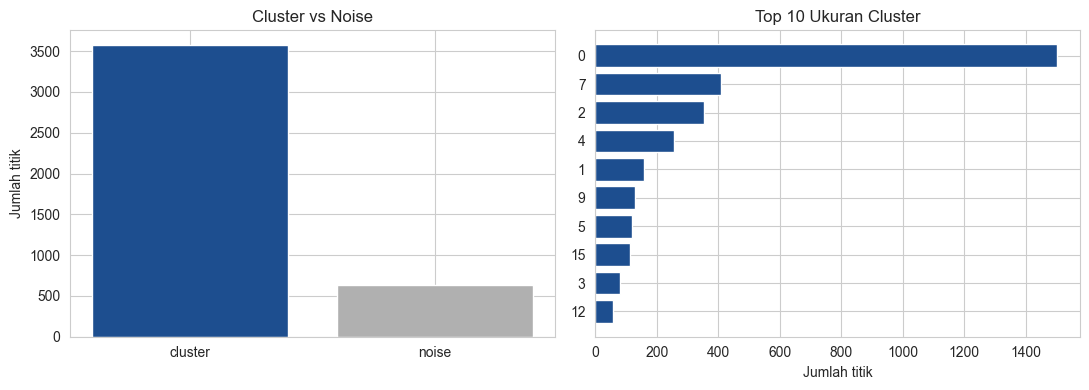

Cluster vs noise disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\cluster_vs_noise.png


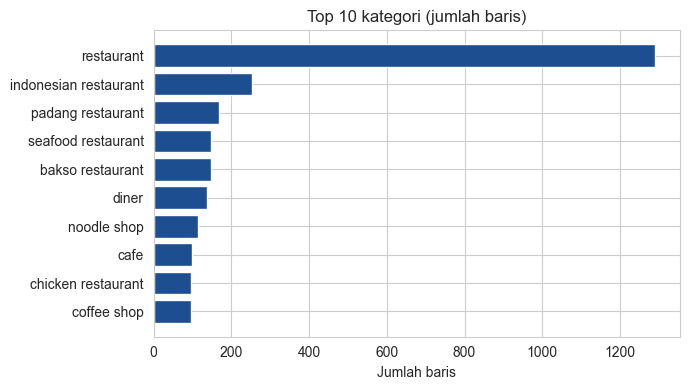

Distribusi kategori (Top 10) disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports/category_distribution_top10.png


In [15]:
# ── 5.1 Jalankan DBSCAN ───────────────────────────────────────────────
#
# Input: koordinat UTM (x_utm, y_utm) dalam meter
# metric='euclidean' → jarak lurus antar titik dalam meter (akurat karena UTM)
# algorithm='ball_tree' → lebih efisien untuk data geospasial besar
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

coords_utm = df[['x_utm', 'y_utm']].values

dbscan = DBSCAN(
    eps=EPS_METER,        # radius dalam meter
    min_samples=MIN_SAMPLES,
    metric='euclidean',
    algorithm='ball_tree',
    n_jobs=-1             # gunakan semua CPU core
)

print(f"Menjalankan DBSCAN dengan eps={EPS_METER}m, min_samples={MIN_SAMPLES}...")
df['cluster_id'] = dbscan.fit_predict(coords_utm)

# ── Hasil ringkas ─────────────────────────────────────────────────────
n_clusters  = len(set(df['cluster_id'])) - (1 if -1 in df['cluster_id'].values else 0)
n_noise     = (df['cluster_id'] == -1).sum()
n_clustered = (df['cluster_id'] >= 0).sum()

summary_dbscan = pd.DataFrame([
    {"metrik": "Jumlah cluster", "nilai": n_clusters},
    {"metrik": "Titik dalam cluster", "nilai": n_clustered},
    {"metrik": "Titik noise (-1)", "nilai": n_noise},
    {"metrik": "Noise ratio (%)", "nilai": round(n_noise/len(df)*100, 1)},
])
print("\nRingkasan DBSCAN:")
display(summary_dbscan)

cluster_sizes = df[df['cluster_id'] >= 0]['cluster_id'].value_counts().reset_index()
cluster_sizes.columns = ['cluster_id', 'count']
cluster_sizes = cluster_sizes.sort_values('count', ascending=False)
print("\nTop 10 cluster terbesar:")
display(cluster_sizes.head(10))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["cluster", "noise"], [n_clustered, n_noise], color=["#1D4E8F", "#B0B0B0"])
axes[0].set_title("Cluster vs Noise")
axes[0].set_ylabel("Jumlah titik")

top_n = min(10, len(cluster_sizes))
axes[1].barh(cluster_sizes['cluster_id'].head(top_n).astype(str), cluster_sizes['count'].head(top_n), color="#1D4E8F")
axes[1].set_title(f"Top {top_n} Ukuran Cluster")
axes[1].invert_yaxis()
axes[1].set_xlabel("Jumlah titik")

plt.tight_layout()
cluster_noise_path = os.path.join(REPORT_DIR, "cluster_vs_noise.png")
plt.savefig(cluster_noise_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Cluster vs noise disimpan: {cluster_noise_path}")

# ── Distribusi kategori (Top 10) ──────────────────────────────────────
if CAT_COL in df.columns:
    cat_counts = df[CAT_COL].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(cat_counts.index.astype(str), cat_counts.values, color="#1D4E8F")
    ax.set_title("Top 10 kategori (jumlah baris)")
    ax.set_xlabel("Jumlah baris")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{REPORT_DIR}/category_distribution_top10.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Distribusi kategori (Top 10) disimpan: {REPORT_DIR}/category_distribution_top10.png")
else:
    print("Kolom kategori tidak ditemukan untuk distribusi Top 10.")

Metrik evaluasi clustering:


,metrik,nilai,target
0,Silhouette Score,0.4396,> 0.3
1,Davies-Bouldin Index,0.3735,< 1.0


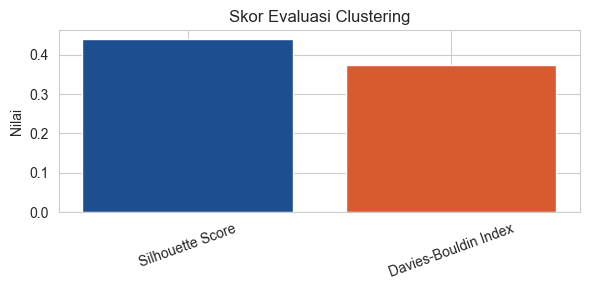

✓ Silhouette Score acceptable (0.4396)


In [16]:
# ── 5.2 Evaluasi Kualitas Clustering ─────────────────────────────────
#
# Kita gunakan DUA metrik evaluasi clustering yang disebutkan di PRD:
#
# 1. SILHOUETTE SCORE
#    Rentang: -1 hingga +1
#    +1 = cluster sangat terpisah dengan baik
#     0 = titik berada di batas antar cluster
#    -1 = titik salah cluster
#    Target: > 0.3 (acceptable), > 0.5 (good)
#
# 2. DAVIES-BOULDIN INDEX
#    Rentang: 0 hingga tak terhingga
#    Semakin KECIL semakin baik
#    0 = cluster sempurna
#    Target: < 1.0
#
# CATATAN: Kedua metrik ini hanya bisa dihitung untuk titik yang MASUK cluster
# (cluster_id >= 0). Titik noise (-1) dikecualikan.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

df_clustered = df[df['cluster_id'] >= 0]

if len(df_clustered) > 0 and n_clusters >= 2:
    X_eval = df_clustered[['x_utm', 'y_utm']].values
    y_eval = df_clustered['cluster_id'].values

    # Silhouette Score (sample untuk efisiensi jika data besar)
    sample_size = min(5000, len(df_clustered))
    sil_score = silhouette_score(
        X_eval, y_eval,
        sample_size=sample_size,
        random_state=RANDOM_SEED
    )

    # Davies-Bouldin Index
    db_score = davies_bouldin_score(X_eval, y_eval)

    metrics_df = pd.DataFrame([
        {"metrik": "Silhouette Score", "nilai": round(sil_score, 4), "target": "> 0.3"},
        {"metrik": "Davies-Bouldin Index", "nilai": round(db_score, 4), "target": "< 1.0"},
    ])
    print("Metrik evaluasi clustering:")
    display(metrics_df)

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(metrics_df["metrik"], metrics_df["nilai"], color=["#1D4E8F", "#D85A30"])
    ax.set_title("Skor Evaluasi Clustering")
    ax.set_ylabel("Nilai")
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

    if sil_score < 0.3:
        print("⚠ Silhouette Score di bawah 0.3.")
        print("  → Coba kurangi EPS_METER (cluster terlalu besar/overlap)")
        print("  → Atau kurangi MIN_SAMPLES jika terlalu banyak noise")
    else:
        print(f"✓ Silhouette Score acceptable ({sil_score:.4f})")
else:
    sil_score = None
    db_score  = None
    print("⚠ Tidak cukup cluster untuk menghitung metrik. Coba kecilkan EPS atau MIN_SAMPLES.")

Statistik jarak ke centroid:


count    3575.00
mean     1357.25
std       959.38
min         3.16
25%       623.13
50%      1183.64
75%      1801.09
max      5049.76
Name: dist_to_cluster_centroid_m, dtype: float64

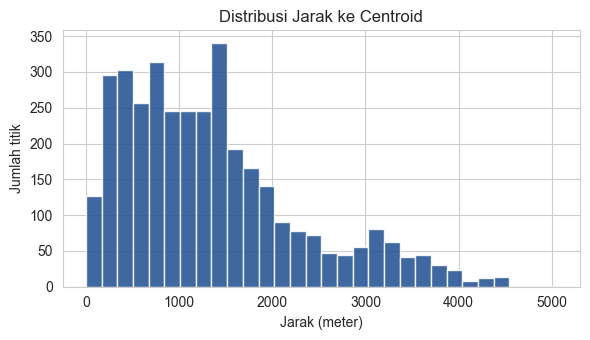


Contoh 5 baris dengan kolom baru:


,name,cluster_id,dist_to_cluster_centroid_m
0,Pacific food court,0,2789.764362
1,Berjaya Masakan Padang,0,2585.152329
2,Warung Kopi HARUM,0,1783.669211
3,Toko Barokah,1,792.786615
4,Multi Bintang Indonesia,1,1101.421899


In [17]:
# ── 5.3 Hitung Centroid per Cluster & Jarak ke Centroid ───────────────
#
# Centroid = titik pusat rata-rata koordinat UTM setiap cluster.
# 'dist_to_cluster_centroid_m' adalah fitur penting untuk Random Forest:
# makin jauh dari centroid = makin di pinggiran zona konsentrasi.
# Titik noise (cluster_id = -1) mendapat dist_to_centroid = NaN → diisi 0.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# Hitung centroid per cluster
centroids = (
    df[df['cluster_id'] >= 0]
    .groupby('cluster_id')[['x_utm', 'y_utm']]
    .mean()
    .rename(columns={'x_utm': 'centroid_x', 'y_utm': 'centroid_y'})
)

# Gabungkan centroid ke df utama
df = df.merge(centroids, on='cluster_id', how='left')

# Hitung jarak Euclidean dari setiap titik ke centroid cluster-nya
df['dist_to_cluster_centroid_m'] = np.sqrt(
    (df['x_utm'] - df['centroid_x'])**2 +
    (df['y_utm'] - df['centroid_y'])**2
).fillna(0)  # noise point → 0

# Hapus kolom centroid sementara (sudah tidak perlu disimpan di feature store)
df = df.drop(columns=['centroid_x', 'centroid_y'])

print("Statistik jarak ke centroid:")
display(df[df['cluster_id'] >= 0]['dist_to_cluster_centroid_m'].describe().round(2))

plt.figure(figsize=(6, 3.5))
plt.hist(df[df['cluster_id'] >= 0]['dist_to_cluster_centroid_m'], bins=30, color="#1D4E8F", alpha=0.85)
plt.title("Distribusi Jarak ke Centroid")
plt.xlabel("Jarak (meter)")
plt.ylabel("Jumlah titik")
plt.tight_layout()
plt.show()

print("\nContoh 5 baris dengan kolom baru:")
display(df[['name', 'cluster_id', 'dist_to_cluster_centroid_m']].head())

Menghitung competitor density... (ini memerlukan beberapa detik)

Statistik fitur density:


,competitor_density_500m,competitor_density_1km,same_category_density_500m,nearest_neighbor_dist_m
count,4206.00,4206.00,4206.00,4206.00
mean,43.68,116.94,5.11,690.64
std,41.64,106.90,9.21,11048.68
min,0.00,0.00,0.00,0.00
25%,12.00,37.00,0.00,15.65
50%,30.00,92.00,1.00,37.47
75%,65.00,167.00,5.00,88.39
max,197.00,471.00,60.00,450249.54


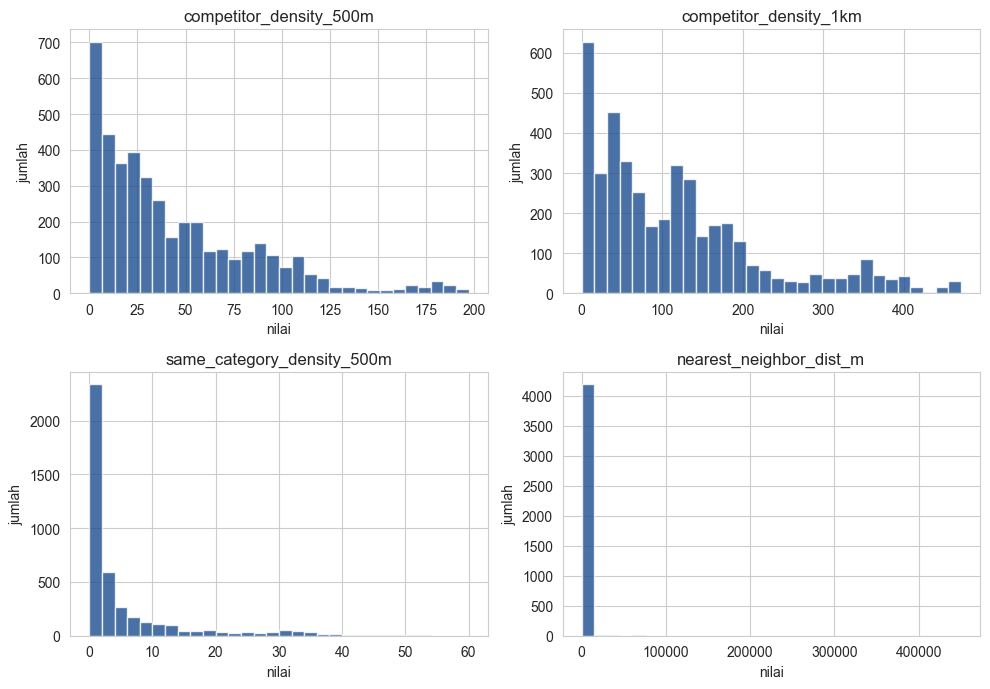

In [18]:
# ── 5.4 Hitung Fitur Density (Kompetitor dalam Radius) ────────────────
#
# Ini adalah dua fitur geospasial paling penting untuk Random Forest:
#   - competitor_density_500m: semua usaha dalam 500m
#   - same_category_density_500m: usaha kategori SAMA dalam 500m
#
# Cara kerja:
# Untuk setiap titik A, hitung berapa titik lain yang jaraknya ≤ radius.
# Kita gunakan BallTree dari scikit-learn untuk efisiensi O(n log n).
# Tanpa BallTree, kompleksitasnya O(n²) — sangat lambat untuk 75k+ titik.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

coords_for_tree = df[['x_utm', 'y_utm']].values
tree = BallTree(coords_for_tree, metric='euclidean')

print("Menghitung competitor density... (ini memerlukan beberapa detik)")

# --- competitor_density_500m: semua usaha dalam 500m (termasuk diri sendiri) ---
counts_500m = tree.query_radius(coords_for_tree, r=RADIUS_500M, count_only=True)
# Kurangi 1 karena setiap titik menghitung dirinya sendiri
df['competitor_density_500m'] = counts_500m - 1

# --- competitor_density_1km: semua usaha dalam 1km ---
counts_1km = tree.query_radius(coords_for_tree, r=RADIUS_1KM, count_only=True)
df['competitor_density_1km'] = counts_1km - 1

# --- same_category_density_500m: usaha kategori sama dalam 500m ---
# Dilakukan per kategori untuk efisiensi
df['same_category_density_500m'] = 0

if CAT_COL in df.columns:
    for cat in df[CAT_COL].unique():
        cat_mask  = df[CAT_COL] == cat
        cat_coords = df.loc[cat_mask, ['x_utm', 'y_utm']].values

        if len(cat_coords) < 2:
            continue

        cat_tree   = BallTree(cat_coords, metric='euclidean')
        cat_counts = cat_tree.query_radius(cat_coords, r=RADIUS_500M, count_only=True)
        df.loc[cat_mask, 'same_category_density_500m'] = cat_counts - 1

# --- nearest_neighbor_dist_m: jarak ke usaha terdekat ---
# k=2 karena k=1 adalah titik itu sendiri (jarak=0)
dist_nn, _ = tree.query(coords_for_tree, k=2)
df['nearest_neighbor_dist_m'] = dist_nn[:, 1]  # ambil tetangga ke-2 (bukan diri sendiri)

density_cols = [
    'competitor_density_500m',
    'competitor_density_1km',
    'same_category_density_500m',
    'nearest_neighbor_dist_m'
]
print("\nStatistik fitur density:")
display(df[density_cols].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()
for i, col in enumerate(density_cols):
    axes[i].hist(df[col], bins=30, color="#1D4E8F", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("nilai")
    axes[i].set_ylabel("jumlah")

plt.tight_layout()
plt.show()

---
# Tahap 7 — Visualisasi Hasil Clustering

Visualisasi wajib dilakukan sebelum menyimpan output. Tujuannya bukan hanya untuk laporan — tapi untuk **sanity check**: apakah cluster yang terbentuk masuk akal secara geografis?

Hal yang perlu diperiksa:
1. Apakah cluster terbentuk di area yang memang ramai? (Nagoya, Batam Center, Batu Aji)
2. Apakah titik noise (-1) menyebar di area pinggiran?
3. Apakah tidak ada cluster tunggal raksasa yang mencakup seluruh Batam? (jika ya, EPS terlalu besar)

Ringkasan hasil DBSCAN:


,metrik,nilai
0,Jumlah cluster,26.0
1,Titik dalam cluster,3575.0
2,Titik noise,631.0
3,Noise ratio (%),15.0


Statistik ukuran cluster:


,nilai
count,26.00
mean,137.50
std,297.57
min,10.00
25%,18.25
50%,38.50
75%,117.75
max,1502.00


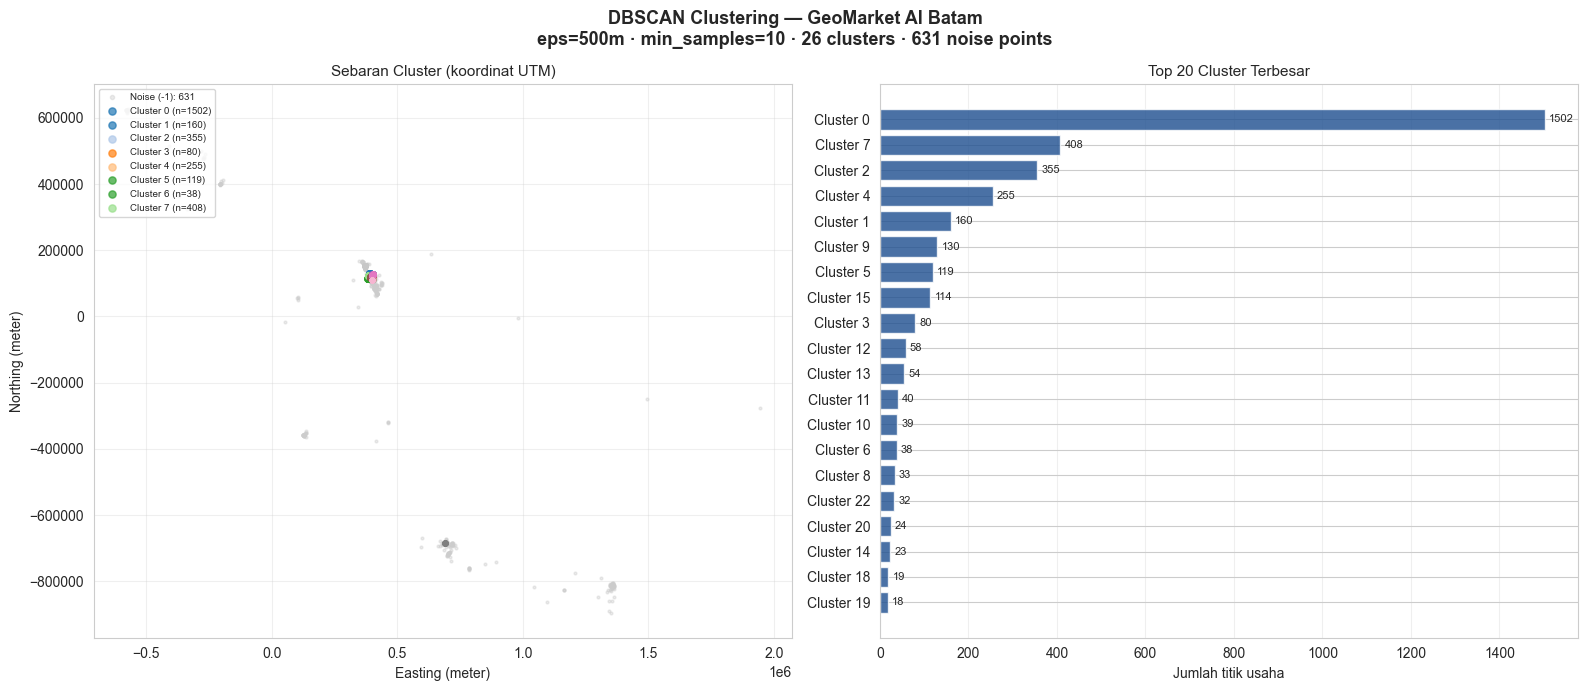

Visualisasi disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports/clustering_result.png


In [19]:
# ── 6.1 Peta Sebaran Cluster ──────────────────────────────────────────
from IPython.display import display
import pandas as pd

summary_vis = pd.DataFrame([
    {"metrik": "Jumlah cluster", "nilai": n_clusters},
    {"metrik": "Titik dalam cluster", "nilai": n_clustered},
    {"metrik": "Titik noise", "nilai": n_noise},
    {"metrik": "Noise ratio (%)", "nilai": round(n_noise / len(df) * 100, 1)},
])
print("Ringkasan hasil DBSCAN:")
display(summary_vis)

cluster_sizes_all = df[df['cluster_id'] >= 0]['cluster_id'].value_counts().sort_values(ascending=False)
cluster_stats = cluster_sizes_all.describe().round(2).to_frame(name="nilai")
print("Statistik ukuran cluster:")
display(cluster_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'DBSCAN Clustering — GeoMarket AI Batam\n'
    f'eps={EPS_METER}m · min_samples={MIN_SAMPLES} · '
    f'{n_clusters} clusters · {n_noise} noise points',
    fontsize=13, fontweight='bold'
 )

# ── Plot kiri: sebaran semua cluster dengan warna unik ────────────────
ax1 = axes[0]

# Titik noise → abu-abu kecil
noise_mask = df['cluster_id'] == -1
ax1.scatter(
    df.loc[noise_mask, 'x_utm'],
    df.loc[noise_mask, 'y_utm'],
    c='#CCCCCC', s=4, alpha=0.4, label=f'Noise (-1): {n_noise:,}', zorder=1
 )

# Titik cluster → warna berbeda per cluster
cluster_ids = sorted(df[df['cluster_id'] >= 0]['cluster_id'].unique())
colors = cm.tab20(np.linspace(0, 1, max(len(cluster_ids), 1)))

for i, cid in enumerate(cluster_ids[:20]):  # tampilkan maks 20 cluster
    mask = df['cluster_id'] == cid
    count = mask.sum()
    ax1.scatter(
        df.loc[mask, 'x_utm'],
        df.loc[mask, 'y_utm'],
        c=[colors[i]], s=12, alpha=0.7,
        label=f'Cluster {cid} (n={count})' if i < 8 else None,
        zorder=2
    )

ax1.set_title('Sebaran Cluster (koordinat UTM)', fontsize=11)
ax1.set_xlabel('Easting (meter)')
ax1.set_ylabel('Northing (meter)')
ax1.legend(loc='upper left', fontsize=7, ncol=1, markerscale=1.5)
ax1.grid(True, alpha=0.3)

# ── Plot kanan: distribusi ukuran cluster ─────────────────────────────
ax2 = axes[1]

top_n = min(20, len(cluster_sizes_all))
top_clusters = cluster_sizes_all.head(top_n)

bars = ax2.barh(
    [f'Cluster {i}' for i in top_clusters.index],
    top_clusters.values,
    color='#1D4E8F', alpha=0.8, edgecolor='white'
 )
ax2.bar_label(bars, padding=3, fontsize=8)
ax2.invert_yaxis()
ax2.set_title(f'Top {top_n} Cluster Terbesar', fontsize=11)
ax2.set_xlabel('Jumlah titik usaha')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/clustering_result.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Visualisasi disimpan: {REPORT_DIR}/clustering_result.png")

---
## Tahap 7.3 — Tuning Grid DBSCAN (Auto Ranking)

Grid sederhana untuk mencari kombinasi EPS dan min_samples terbaik
berdasarkan Silhouette, Davies-Bouldin, dan noise ratio.

In [20]:
# ── 6.3 Tuning Grid DBSCAN (Auto Ranking) ─────────────────────────────
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from IPython.display import display

# Parameter grid (sesuaikan jika perlu)
eps_grid = [80, 100, 120, 150, 180, 200]
min_samples_grid = [4, 5, 6, 8]

results = []
coords = df[['x_utm', 'y_utm']].values

for eps in eps_grid:
    for ms in min_samples_grid:
        model = DBSCAN(eps=eps, min_samples=ms, metric='euclidean', algorithm='ball_tree', n_jobs=-1)
        labels = model.fit_predict(coords)
        n_noise_local = (labels == -1).sum()
        n_clustered_local = (labels >= 0).sum()
        n_clusters_local = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio_local = n_noise_local / len(labels) if len(labels) else 1.0

        sil = None
        dbi = None
        if n_clusters_local >= 2 and n_clustered_local > 0:
            X_eval = coords[labels >= 0]
            y_eval = labels[labels >= 0]
            sample_size = min(5000, len(y_eval))
            sil = float(silhouette_score(X_eval, y_eval, sample_size=sample_size, random_state=RANDOM_SEED))
            dbi = float(davies_bouldin_score(X_eval, y_eval))

        results.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters_local,
            "noise_ratio": round(noise_ratio_local * 100, 2),
            "silhouette": None if sil is None else round(sil, 4),
            "davies_bouldin": None if dbi is None else round(dbi, 4),
        })

df_grid = pd.DataFrame(results)
print("Hasil grid search (ringkas):")
display(df_grid)

# Ranking: prioritaskan silhouette tinggi, DB rendah, noise ratio rendah
df_rank = df_grid.copy()
df_rank['silhouette_rank'] = df_rank['silhouette'].fillna(-1)
df_rank['db_rank'] = df_rank['davies_bouldin'].fillna(9999)
df_rank = df_rank.sort_values(["silhouette_rank", "db_rank", "noise_ratio"], ascending=[False, True, True])
print("\nTop 10 rekomendasi parameter:")
display(df_rank.head(10))

Hasil grid search (ringkas):


,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin
0,80,4,190,49.14,0.5759,0.3837
1,80,5,125,57.04,0.6218,0.3503
2,80,6,102,61.91,0.6404,0.3241
3,80,8,73,70.57,0.6918,0.3299
4,100,4,195,40.09,0.4990,0.4205
5,100,5,141,47.62,0.5453,0.4113
6,100,6,113,53.45,0.5732,0.3760
7,100,8,74,62.53,0.6589,0.3324
8,120,4,180,34.26,0.4834,0.4232
9,120,5,141,40.56,0.5053,0.4439



Top 10 rekomendasi parameter:


,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,silhouette_rank,db_rank
3,80,8,73,70.57,0.6918,0.3299,0.6918,0.3299
11,120,8,78,55.47,0.6658,0.3376,0.6658,0.3376
7,100,8,74,62.53,0.6589,0.3324,0.6589,0.3324
2,80,6,102,61.91,0.6404,0.3241,0.6404,0.3241
1,80,5,125,57.04,0.6218,0.3503,0.6218,0.3503
0,80,4,190,49.14,0.5759,0.3837,0.5759,0.3837
6,100,6,113,53.45,0.5732,0.3760,0.5732,0.3760
10,120,6,115,45.63,0.5664,0.4136,0.5664,0.4136
15,150,8,84,44.22,0.5539,0.3988,0.5539,0.3988
5,100,5,141,47.62,0.5453,0.4113,0.5453,0.4113


---
# Tahap 8 — Simpan ke Feature Store

Feature Store adalah tabel terproses yang menjadi **satu-satunya sumber data** untuk:
- Training Random Forest (Notebook 02)
- Serving API (prediksi real-time)

Dengan memisahkan Feature Store dari raw data, kita memastikan:
- Training dan serving menggunakan fitur yang identik
- Tidak ada kebocoran logika preprocessing antara training dan production
- Jika data baru masuk, cukup jalankan ulang notebook ini

In [21]:
# ── 7.1 Tentukan kolom yang masuk Feature Store ───────────────────────
#
# Kolom identifier: untuk referensi
# Kolom koordinat: lat/lon asli + UTM untuk keperluan spasial
# Kolom cluster: hasil DBSCAN
# Kolom density: fitur geospasial
# Kolom atribut: fitur dari data usaha

# Kolom identifier
id_cols = ['id', 'name', CAT_COL]
id_cols = [c for c in id_cols if c in df.columns]

# Metadata sumber (tidak dipakai untuk training)
meta_cols = [c for c in ['source_category', 'source_file', 'source_table'] if c in df.columns]

# Kolom koordinat
coord_cols = [LAT_COL, LON_COL, 'x_utm', 'y_utm']

# Kolom hasil clustering
cluster_cols = ['cluster_id', 'dist_to_cluster_centroid_m']

# Kolom density (fitur geospasial)
density_cols = [
    'competitor_density_500m',
    'competitor_density_1km',
    'same_category_density_500m',
    'nearest_neighbor_dist_m'
 ]

# Kolom atribut usaha
attr_cols = []
for col in ['rating', 'review_log', 'price_level']:
    if col in df.columns:
        attr_cols.append(col)

# Gabungkan semua kolom
feature_cols = id_cols + meta_cols + coord_cols + cluster_cols + density_cols + attr_cols
feature_cols = [c for c in feature_cols if c in df.columns]

# Hapus kolom yang seluruhnya kosong
empty_cols = [c for c in feature_cols if df[c].isna().all()]
feature_cols = [c for c in feature_cols if c not in empty_cols]

if empty_cols:
    print("Kolom kosong dihapus dari Feature Store:")
    for col in empty_cols:
        print(f"  - {col}")

df_feature_store = df[feature_cols].copy()

print(f"Kolom dalam Feature Store ({len(feature_cols)} total):")
for col in feature_cols:
    dtype = df_feature_store[col].dtype
    null_count = df_feature_store[col].isnull().sum()
    print(f"  {col:<35} {str(dtype):<10} null: {null_count}")

Kolom dalam Feature Store (19 total):
  id                                  int64      null: 0
  name                                str        null: 0
  category                            str        null: 0
  source_category                     str        null: 0
  source_file                         str        null: 0
  source_table                        str        null: 0
  latitude                            float64    null: 0
  longitude                           float64    null: 0
  x_utm                               float64    null: 0
  y_utm                               float64    null: 0
  cluster_id                          int64      null: 0
  dist_to_cluster_centroid_m          float64    null: 0
  competitor_density_500m             int64      null: 0
  competitor_density_1km              int64      null: 0
  same_category_density_500m          int64      null: 0
  nearest_neighbor_dist_m             float64    null: 0
  rating                              float64    n

In [22]:
# ── 7.2 Simpan Feature Store ──────────────────────────────────────────
df_feature_store.to_csv(FEATURE_STORE_PATH, index=False)
print(f"✓ Feature Store disimpan: {FEATURE_STORE_PATH}")
print(f"  Shape: {df_feature_store.shape}")
print(f"  Ukuran file: {os.path.getsize(FEATURE_STORE_PATH)/1024:.1f} KB")

print(f"\nSampel 3 baris Feature Store:")
df_feature_store.head(3)

✓ Feature Store disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\data\feature_store.csv
  Shape: (4206, 19)
  Ukuran file: 907.5 KB

Sampel 3 baris Feature Store:


,id,name,category,source_category,source_file,source_table,latitude,longitude,x_utm,y_utm,cluster_id,dist_to_cluster_centroid_m,competitor_density_500m,competitor_density_1km,same_category_density_500m,nearest_neighbor_dist_m,rating,review_log,price_level
0,96,Pacific food court,restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places,1.151015,104.000602,388808.675066,127241.394226,0,2789.764362,30,155,8,234.484959,4.4,5.455321,2
1,193,Berjaya Masakan Padang,padang restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db,places,1.154278,104.005409,389343.640633,127601.867659,0,2585.152329,38,127,5,32.238366,4.0,1.386294,0
2,211,Warung Kopi HARUM,noodle shop,F&B,Indonesia.Batam.Kuliner.202406162232.db,places,1.150087,104.011475,390018.406080,127138.429168,0,1783.669211,128,348,4,0.000000,4.4,5.717028,0


In [23]:
# ── 7.3 Simpan Metadata Clustering ───────────────────────────────────
#
# Metadata wajib disimpan untuk:
# - Reproducibility: tahu persis kondisi saat model ini dilatih
# - Version control: bandingkan metrik antar run
# - Admin dashboard: ditampilkan saat trigger retraining
import os
import json
import datetime

db_file_names = [os.path.basename(p) for p in db_files] if 'db_files' in globals() else []

metadata = {
    "notebook"         : "01_dbscan_clustering",
    "timestamp"        : datetime.datetime.now().isoformat(),
    "target_db"        : TARGET_DB_FILE,
    "db_files"         : db_file_names,
    "paths"            : {
        "run_dir"           : RUN_DIR,
        "data_dir"          : OUTPUT_DIR,
        "report_dir"        : REPORT_DIR,
        "model_dir"         : MODEL_DIR,
        "feature_store_path": FEATURE_STORE_PATH,
    },
    "params"           : {
        "eps_meter"         : EPS_METER,
        "min_samples"       : MIN_SAMPLES,
        "category_col"      : CAT_COL,
        "crs_input"         : CRS_WGS84,
        "crs_output"        : CRS_UTM48N,
    },
    "results": {
        "n_clusters"         : int(n_clusters),
        "n_noise"            : int(n_noise),
        "n_clustered"        : int(n_clustered),
        "noise_ratio_pct"    : round(n_noise / len(df) * 100, 2),
        "silhouette_score"   : round(sil_score, 4) if sil_score else None,
        "davies_bouldin_idx" : round(db_score, 4)  if db_score  else None
    },
    "output": {
        "feature_columns"    : feature_cols
    }
}

with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata disimpan: {METADATA_PATH}")
print(f"\nIsi metadata:")
print(json.dumps(metadata, indent=2))

✓ Metadata disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\models\clustering_metadata.json

Isi metadata:
{
  "notebook": "01_dbscan_clustering",
  "timestamp": "2026-06-18T21:48:00.820963",
  "target_db": "Indonesia.Batam.Kuliner.202406162232.db",
  "db_files": [
    "Indonesia.Batam.Kuliner.202406162232.db"
  ],
  "paths": {
    "run_dir": "content/runs\\Indonesia.Batam.Kuliner.202406162232",
    "data_dir": "content/runs\\Indonesia.Batam.Kuliner.202406162232\\data",
    "report_dir": "content/runs\\Indonesia.Batam.Kuliner.202406162232\\reports",
    "model_dir": "content/runs\\Indonesia.Batam.Kuliner.202406162232\\models",
    "feature_store_path": "content/runs\\Indonesia.Batam.Kuliner.202406162232\\data\\feature_store.csv"
  },
  "params": {
    "eps_meter": 500,
    "min_samples": 10,
    "category_col": "category",
    "crs_input": "EPSG:4326",
    "crs_output": "EPSG:32648"
  },
  "results": {
    "n_clusters": 26,
    "n_noise": 631,
    "n_clustered": 3575,
    "n

---
## Ringkasan & Langkah Selanjutnya

### Yang sudah diselesaikan notebook ini:

| Tahap | Status | Output |
|---|---|---|
| Ingestion dari SQLite | ✓ | DataFrame raw |
| Validation Gate (4 aturan) | ✓ | `rejected_rows.csv` |
| Konversi WGS84 → UTM | ✓ | Kolom `x_utm`, `y_utm` |
| DBSCAN Clustering | ✓ | Kolom `cluster_id` |
| Evaluasi (Silhouette + DB Index) | ✓ | Tercatat di metadata |
| Hitung centroid & jarak | ✓ | Kolom `dist_to_cluster_centroid_m` |
| Hitung fitur density | ✓ | 4 kolom density |
| Simpan Feature Store | ✓ | `feature_store.csv` |
| Simpan Metadata | ✓ | `clustering_metadata.json` |

### Sebelum lanjut ke Notebook 02 (Random Forest), pastikan:

1. **Silhouette Score > 0.3** — jika tidak, tuning `EPS_METER` di Tahap 6
2. **Noise ratio < 30%** — jika lebih, kemungkinan `EPS` terlalu kecil atau `MIN_SAMPLES` terlalu besar
3. **Cluster masuk akal geografis** — periksa visualisasi, cluster harus terbentuk di area yang memang ramai (Nagoya Hill, Batam Center, Batu Aji, dll)
4. **Feature Store tidak ada null** — cek kolom `cluster_id` dan `dist_to_cluster_centroid_m`

### Panduan tuning cepat:

| Gejala | Solusi |
|---|---|
| Terlalu banyak noise (>40%) | Besarkan `EPS_METER` atau kecilkan `MIN_SAMPLES` |
| Semua jadi satu cluster besar | Kecilkan `EPS_METER` |
| Terlalu banyak cluster kecil | Besarkan `MIN_SAMPLES` |
| Silhouette Score negatif | `EPS` terlalu besar, cluster overlap |

### File output:
```
content/
└── runs/
    └── <db_key>/
        ├── data/
        │   ├── feature_store.csv         ← input untuk Notebook 02
        │   └── rejected_rows.csv         ← data yang ditolak Validation Gate
        ├── reports/
        │   └── clustering_result.png     ← visualisasi sebaran cluster
        └── models/
            └── clustering_metadata.json  ← metadata run ini
```

In [24]:
# ── Final Sanity Check ────────────────────────────────────────────────
# Jalankan cell ini terakhir untuk memastikan semua output tersedia

print("="*55)
print("  FINAL CHECK — Notebook 01 DBSCAN Clustering")
print("="*55)

checks = [
    (FEATURE_STORE_PATH, "Feature Store CSV"),
    (METADATA_PATH,      "Clustering Metadata JSON"),
    (f"{OUTPUT_DIR}/rejected_rows.csv",      "Rejected Rows Log"),
    (f"{REPORT_DIR}/clustering_result.png",  "Visualisasi Cluster"),
]

all_ok = True
for path, label in checks:
    exists = os.path.exists(path)
    status = "✓" if exists else "✗"
    if not exists:
        all_ok = False
    size = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "—"
    print(f"  {status} {label:<30} {size}")

print("="*55)
print(f"  Cluster ID range : {df['cluster_id'].min()} s.d. {df['cluster_id'].max()}")
print(f"  Total data       : {len(df_feature_store):,} baris")
if sil_score:
    print(f"  Silhouette Score : {sil_score:.4f}")
    print(f"  Davies-Bouldin   : {db_score:.4f}")
print("="*55)

if all_ok:
    print("\n✓ Semua output tersedia. Lanjut ke Notebook 02: Random Forest Training.")
else:
    print("\n⚠ Ada output yang belum tersedia. Periksa cell di atas.")

  FINAL CHECK — Notebook 01 DBSCAN Clustering
  ✓ Feature Store CSV              907.5 KB
  ✓ Clustering Metadata JSON       1.5 KB
  ✓ Rejected Rows Log              422.5 KB
  ✓ Visualisasi Cluster            147.9 KB
  Cluster ID range : -1 s.d. 25
  Total data       : 4,206 baris
  Silhouette Score : 0.4396
  Davies-Bouldin   : 0.3735

✓ Semua output tersedia. Lanjut ke Notebook 02: Random Forest Training.


---
# Tahap 9 — Quality Gate DBSCAN

Pastikan konfigurasi DBSCAN sudah menghasilkan cluster yang layak sebelum lanjut ke Random Forest.
Gate ini tidak menghentikan proses, tapi memberi peringatan jika kualitas terlalu rendah.

In [25]:
# ── Quality Gate DBSCAN ───────────────────────────────────────────────
required_vars = ["n_clusters", "n_noise", "df"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    print(f"⚠ Variabel belum tersedia: {missing}")
    print("Jalankan Tahap 5 terlebih dahulu (DBSCAN).")
else:
    noise_ratio = n_noise / len(df) if len(df) > 0 else 1.0
    print("DBSCAN Quality Gate")
    print("-" * 40)
    print(f"Total data        : {len(df):,}")
    print(f"Jumlah cluster    : {n_clusters}")
    print(f"Noise ratio       : {noise_ratio*100:.1f}%")
    if 'sil_score' in globals() and sil_score is not None:
        print(f"Silhouette Score  : {sil_score:.4f}")
    else:
        print("Silhouette Score  : belum dihitung")

    if noise_ratio > 0.4:
        print("⚠ Noise ratio tinggi (>40%). Pertimbangkan menaikkan EPS_METER atau menurunkan MIN_SAMPLES.")
    if 'sil_score' in globals() and sil_score is not None and sil_score < 0.3:
        print("⚠ Silhouette Score < 0.3. Cluster kemungkinan overlap.")
    print("-" * 40)

DBSCAN Quality Gate
----------------------------------------
Total data        : 4,206
Jumlah cluster    : 26
Noise ratio       : 15.0%
Silhouette Score  : 0.4396
----------------------------------------


---
# Tahap 10 — Random Forest Training (Rekomendasi Lokasi)

Tahap ini membuat label proxy `High/Medium/Low` berdasarkan formula PRD,
lalu melatih model Random Forest dengan spatial split untuk menghindari data leakage.

### 10.1 Load Feature Store & Label Proxy

Ringkas: load feature store, buat hotspot score, dan label proxy.

In [26]:
# ── 9.1 Load Feature Store + Buat Label Proxy ─────────────────────────
import os
import numpy as np
import pandas as pd
from sklearn.neighbors import KernelDensity

df_fs = pd.read_csv(FEATURE_STORE_PATH)
print(f"Feature store loaded: {df_fs.shape[0]:,} baris × {df_fs.shape[1]} kolom")

# Kolom wajib untuk label proxy dan perhitungan spasial
base_required = [
    "x_utm", "y_utm",
    "same_category_density_500m",
    "nearest_neighbor_dist_m",
    "dist_to_cluster_centroid_m",
 ]
missing_base = [c for c in base_required if c not in df_fs.columns]
if missing_base:
    raise ValueError(f"Kolom wajib untuk label proxy tidak ditemukan: {missing_base}")
for col in base_required:
    if df_fs[col].isna().all():
        raise ValueError(f"Kolom wajib kosong seluruhnya: {col}")

# Kolom opsional untuk fitur training
optional_cols = ["rating", "review_log", "competitor_density_500m"]
feature_usable = {}

for col in base_required + optional_cols:
    if col not in df_fs.columns:
        df_fs[col] = 0.0
        feature_usable[col] = False
    elif df_fs[col].isna().all():
        df_fs[col] = 0.0
        feature_usable[col] = False
    else:
        df_fs[col] = df_fs[col].fillna(df_fs[col].median())
        feature_usable[col] = True

dropped_cols = [c for c, usable in feature_usable.items() if not usable and c in optional_cols]
if dropped_cols:
    print("Kolom opsional kosong, tidak dipakai untuk training:")
    for col in dropped_cols:
        print(f"  - {col}")

# --- Hotspot score via KDE (jika belum ada) ---
if "hotspot_score" not in df_fs.columns:
    coords = df_fs[["x_utm", "y_utm"]].values
    kde_bandwidth_m = 500.0
    kde = KernelDensity(bandwidth=kde_bandwidth_m, kernel="gaussian")
    kde.fit(coords)
    log_density = kde.score_samples(coords)
    df_fs["hotspot_score"] = np.exp(log_density)
    print("Hotspot score dibuat dengan KDE.")
else:
    print("Hotspot score sudah tersedia.")

# --- Saturation index (proxy) berdasarkan radius 500m ---
area_km2 = np.pi * (0.5 ** 2)
df_fs["saturation_index"] = df_fs["same_category_density_500m"] / area_km2

# --- Suitability score (proxy sesuai PRD) ---
df_fs["suitability_score"] = (
    df_fs["rating"] * 0.25 +
    df_fs["review_log"] * 0.20 +
    df_fs["hotspot_score"] * 0.25 -
    df_fs["same_category_density_500m"] * 0.20 -
    df_fs["saturation_index"] * 0.10
)

q1, q2 = df_fs["suitability_score"].quantile([0.33, 0.66])
df_fs["suitability_label"] = pd.cut(
    df_fs["suitability_score"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"]
)

print("Distribusi label:")
print(df_fs["suitability_label"].value_counts())

Feature store loaded: 4,206 baris × 19 kolom
Hotspot score dibuat dengan KDE.
Distribusi label:
suitability_label
High      1430
Low       1388
Medium    1388
Name: count, dtype: int64


### 10.1b Ringkasan Label (Clean Table)

Ringkas: tampilkan distribusi label dan ambang kuantil.

In [27]:
# ── 9.1b Ringkasan Label (Clean Output) ───────────────────────────────
from IPython.display import display

label_counts = df_fs["suitability_label"].value_counts(dropna=False)
label_pct = (label_counts / label_counts.sum() * 100).round(2)
label_summary = pd.DataFrame({"count": label_counts, "pct": label_pct})

thresholds = pd.DataFrame({"q1": [q1], "q2": [q2]})

display(label_summary)
display(thresholds)

,count,pct
suitability_label,,
High,1430,34.0
Low,1388,33.0
Medium,1388,33.0


,q1,q2
0,1.413568e-09,1.396888


### 10.2 Spatial Split & Train Random Forest

Ringkas: split grid 1km untuk hindari leakage lalu training model.

In [28]:
# ── 9.2 Spatial Split + Train Random Forest ──────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Feature set untuk RF
rf_feature_cols = [
    "rating", "review_log", "hotspot_score",
    "competitor_density_500m", "same_category_density_500m",
    "nearest_neighbor_dist_m", "dist_to_cluster_centroid_m",
    "cluster_id"
 ]
rf_feature_cols = [c for c in rf_feature_cols if c in df_fs.columns and df_fs[c].notna().any()]
if "feature_usable" in globals():
    rf_feature_cols = [c for c in rf_feature_cols if feature_usable.get(c, True)]
if not rf_feature_cols:
    raise ValueError("Tidak ada fitur valid untuk training Random Forest.")

X = df_fs[rf_feature_cols]
y = df_fs["suitability_label"]

# Spatial split berbasis grid 1km untuk menghindari leakage
grid_size_m = 1000
grid_x = (df_fs["x_utm"] // grid_size_m).astype(int)
grid_y = (df_fs["y_utm"] // grid_size_m).astype(int)
df_fs["grid_id"] = grid_x.astype(str) + "_" + grid_y.astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups=df_fs["grid_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1, 
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

print(f"Training data: {X_train.shape}, Test data: {X_test.shape}")
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

f1_macro = f1_score(y_test, pred, average="macro")
cm = confusion_matrix(y_test, pred, labels=["Low", "Medium", "High"])
report_dict = classification_report(y_test, pred, output_dict=True)

print("F1 Macro:", round(f1_macro, 4))
print("Confusion Matrix (Low/Medium/High):")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, pred))

Training data: (3594, 8), Test data: (612, 8)
F1 Macro: 0.9655
Confusion Matrix (Low/Medium/High):
[[169   2   0]
 [  5 180   9]
 [  0   5 242]]

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.98      0.97       247
         Low       0.97      0.99      0.98       171
      Medium       0.96      0.93      0.94       194

    accuracy                           0.97       612
   macro avg       0.97      0.97      0.97       612
weighted avg       0.97      0.97      0.97       612



### 10.2b Evaluasi Model (Table & Visual)

Ringkas: metrik, confusion matrix, dan feature importance.

Ringkasan metrik:


,metric,value
0,f1_macro,0.9655
1,accuracy,0.9657



Classification report (ringkas):


,precision,recall,f1-score,support
Low,0.971264,0.988304,0.979710,171.000000
Medium,0.962567,0.927835,0.944882,194.000000
High,0.964143,0.979757,0.971888,247.000000
accuracy,0.965686,0.965686,0.965686,0.965686
macro avg,0.965992,0.965299,0.965493,612.000000
weighted avg,0.965633,0.965686,0.965513,612.000000



Confusion matrix (table):


,Low,Medium,High
Low,169,2,0
Medium,5,180,9
High,0,5,242


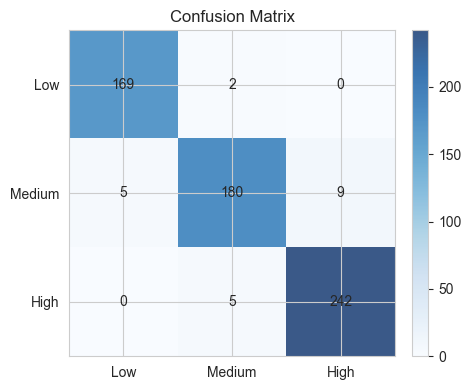

RF confusion matrix disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\rf_confusion_matrix.png


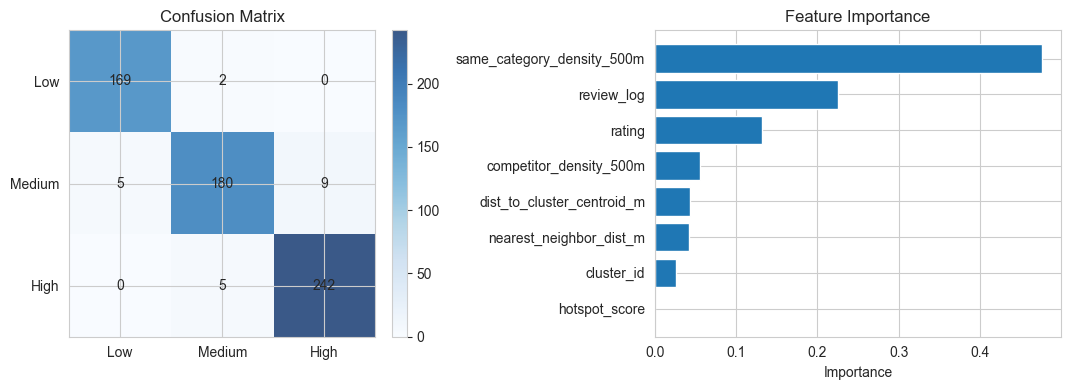

In [29]:
# ── 9.2b Evaluasi Model (Clean Output) ────────────────────────────────
from IPython.display import display
import matplotlib.pyplot as plt
import os

metrics_df = pd.DataFrame({
    "metric": ["f1_macro", "accuracy"],
    "value": [round(f1_macro, 4), round(report_dict.get("accuracy", np.nan), 4)],
})

report_df = pd.DataFrame(report_dict).T
report_view = report_df.loc[
    ["Low", "Medium", "High", "accuracy", "macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"],
]

cm_df = pd.DataFrame(cm, index=["Low", "Medium", "High"], columns=["Low", "Medium", "High"])

print("Ringkasan metrik:")
display(metrics_df)
print("\nClassification report (ringkas):")
display(report_view)
print("\nConfusion matrix (table):")
display(cm_df)

# Simpan confusion matrix
cm_path = os.path.join(REPORT_DIR, "rf_confusion_matrix.png")
fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
im_cm = ax_cm.imshow(cm, cmap="Blues", alpha=0.8)
ax_cm.set_title("Confusion Matrix")
ax_cm.set_xticks(range(3))
ax_cm.set_yticks(range(3))
ax_cm.set_xticklabels(["Low", "Medium", "High"])
ax_cm.set_yticklabels(["Low", "Medium", "High"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax_cm.text(j, i, cm[i, j], ha="center", va="center")
fig_cm.colorbar(im_cm, ax=ax_cm, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"RF confusion matrix disimpan: {cm_path}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix heatmap
ax = axes[0]
im = ax.imshow(cm, cmap="Blues", alpha=0.8)
ax.set_title("Confusion Matrix")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(["Low", "Medium", "High"])
ax.set_yticklabels(["Low", "Medium", "High"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Feature importance
ax = axes[1]
importances = pd.Series(rf.feature_importances_, index=rf_feature_cols).sort_values(ascending=True)
ax.barh(importances.index, importances.values)
ax.set_title("Feature Importance")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

### 10.2c Learning Curve (Spatial Group CV)

Ringkas: evaluasi perubahan train/validation macro-F1 saat jumlah data
training bertambah. Cross-validation memakai grup grid spasial dari training
partition agar validation grid tidak bocor ke training grid.


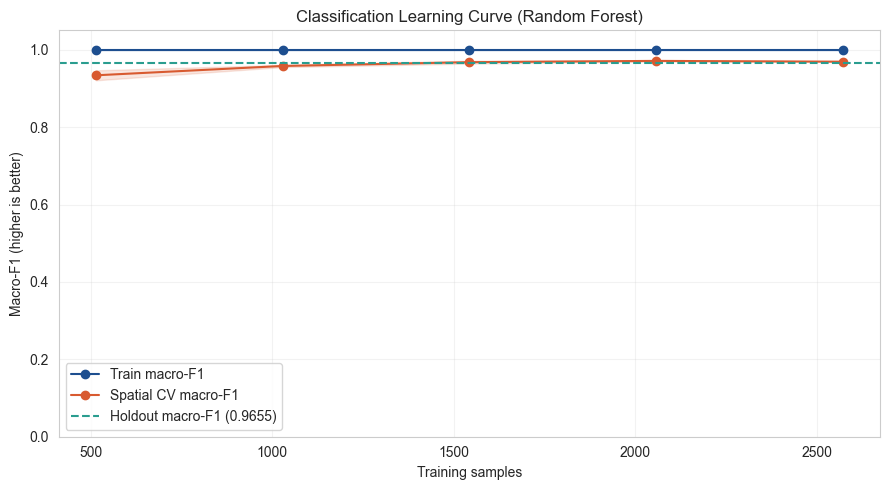

Classification learning curve:


,train_size,train_f1_macro_mean,train_f1_macro_std,validation_f1_macro_mean,validation_f1_macro_std,generalization_gap,fit_time_mean_seconds,score_time_mean_seconds,cv_splits,spatial_group_count
0,514,1.0,0.0,0.933981,0.012875,0.066019,0.624554,0.100488,3,426
1,1028,1.0,0.0,0.958096,0.002889,0.041904,0.684899,0.096267,3,426
2,1542,1.0,0.0,0.967911,0.003636,0.032089,0.677530,0.091203,3,426
3,2056,1.0,0.0,0.971227,0.001730,0.028773,0.728717,0.099560,3,426
4,2571,1.0,0.0,0.969170,0.000563,0.030830,0.709628,0.092144,3,426


Learning curve CSV saved: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\classification_learning_curve.csv
Learning curve plot saved: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\classification_learning_curve.png


In [30]:
from sklearn.base import clone
from sklearn.model_selection import GroupKFold, learning_curve

learning_curve_df = pd.DataFrame()
learning_curve_csv_path = None
learning_curve_plot_path = None

X_learning = X_train.reset_index(drop=True)
y_learning = y_train.reset_index(drop=True)
learning_groups = df_fs.iloc[train_idx]["grid_id"].reset_index(drop=True)
learning_group_count = int(learning_groups.nunique())

def macro_f1_scorer(estimator, X_eval, y_eval):
    predicted_labels = estimator.predict(X_eval)
    return float(
        f1_score(
            y_eval,
            predicted_labels,
            labels=["Low", "Medium", "High"],
            average="macro",
            zero_division=0,
        )
    )

if learning_group_count < 2 or len(X_learning) < 10:
    print(
        "Learning curve skipped: requires at least 2 spatial groups "
        "and 10 training rows."
    )
else:
    learning_cv_splits = min(3, learning_group_count)
    learning_cv = GroupKFold(
        n_splits=learning_cv_splits,
        shuffle=True,
        random_state=RANDOM_SEED,
    )

    (
        learning_train_sizes,
        learning_train_scores,
        learning_validation_scores,
        learning_fit_times,
        learning_score_times,
    ) = learning_curve(
        estimator=clone(rf),
        X=X_learning,
        y=y_learning,
        groups=learning_groups,
        train_sizes=np.linspace(0.2, 1.0, 5),
        cv=learning_cv,
        scoring=macro_f1_scorer,
        n_jobs=1,
        shuffle=True,
        random_state=RANDOM_SEED,
        return_times=True,
    )

    learning_curve_df = pd.DataFrame({
        "train_size": learning_train_sizes.astype(int),
        "train_f1_macro_mean": np.nanmean(learning_train_scores, axis=1),
        "train_f1_macro_std": np.nanstd(learning_train_scores, axis=1),
        "validation_f1_macro_mean": np.nanmean(learning_validation_scores, axis=1),
        "validation_f1_macro_std": np.nanstd(learning_validation_scores, axis=1),
        "generalization_gap": (
            np.nanmean(learning_train_scores, axis=1)
            - np.nanmean(learning_validation_scores, axis=1)
        ),
        "fit_time_mean_seconds": np.nanmean(learning_fit_times, axis=1),
        "score_time_mean_seconds": np.nanmean(learning_score_times, axis=1),
        "cv_splits": learning_cv_splits,
        "spatial_group_count": learning_group_count,
    })

    learning_curve_csv_path = os.path.join(
        REPORT_DIR,
        "classification_learning_curve.csv",
    )
    learning_curve_df.to_csv(learning_curve_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        learning_curve_df["train_size"],
        learning_curve_df["train_f1_macro_mean"],
        marker="o",
        color="#1D4E8F",
        label="Train macro-F1",
    )
    ax.fill_between(
        learning_curve_df["train_size"],
        learning_curve_df["train_f1_macro_mean"]
        - learning_curve_df["train_f1_macro_std"],
        learning_curve_df["train_f1_macro_mean"]
        + learning_curve_df["train_f1_macro_std"],
        color="#1D4E8F",
        alpha=0.15,
    )
    ax.plot(
        learning_curve_df["train_size"],
        learning_curve_df["validation_f1_macro_mean"],
        marker="o",
        color="#D85A30",
        label="Spatial CV macro-F1",
    )
    ax.fill_between(
        learning_curve_df["train_size"],
        learning_curve_df["validation_f1_macro_mean"]
        - learning_curve_df["validation_f1_macro_std"],
        learning_curve_df["validation_f1_macro_mean"]
        + learning_curve_df["validation_f1_macro_std"],
        color="#D85A30",
        alpha=0.15,
    )
    ax.axhline(
        float(f1_macro),
        color="#2A9D8F",
        linestyle="--",
        linewidth=1.5,
        label=f"Holdout macro-F1 ({f1_macro:.4f})",
    )
    ax.set_title("Classification Learning Curve (Random Forest)")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("Macro-F1 (higher is better)")
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()

    learning_curve_plot_path = os.path.join(
        REPORT_DIR,
        "classification_learning_curve.png",
    )
    plt.savefig(learning_curve_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Classification learning curve:")
    display(learning_curve_df)
    print(f"Learning curve CSV saved: {learning_curve_csv_path}")
    print(f"Learning curve plot saved: {learning_curve_plot_path}")


### 10.2c SHAP Explainability (Global + Local)

Ringkas: interpretasi global dan contoh lokal prediksi.

SHAP Global Importance (mean |SHAP|):


,feature,mean_abs_shap
0,same_category_density_500m,0.226268
1,review_log,0.117332
2,rating,0.078386
3,competitor_density_500m,0.022337
4,dist_to_cluster_centroid_m,0.013969
5,cluster_id,0.011470
6,nearest_neighbor_dist_m,0.006740
7,hotspot_score,0.000000


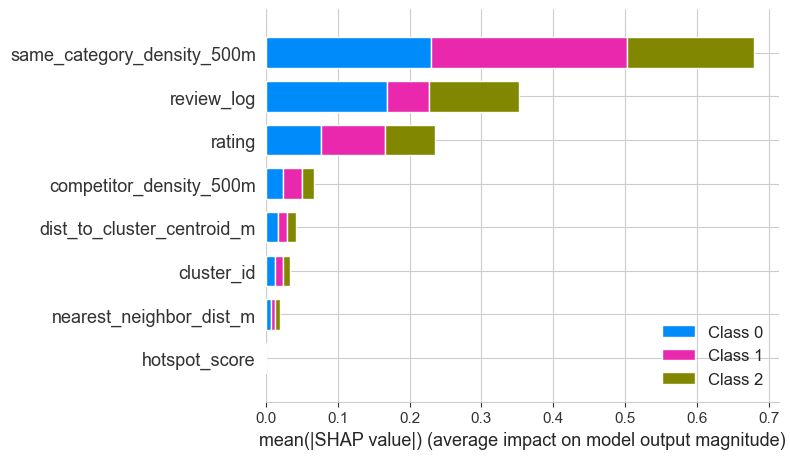

SHAP summary disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\rf_shap_summary.png
Local explanation sample — Pred: High


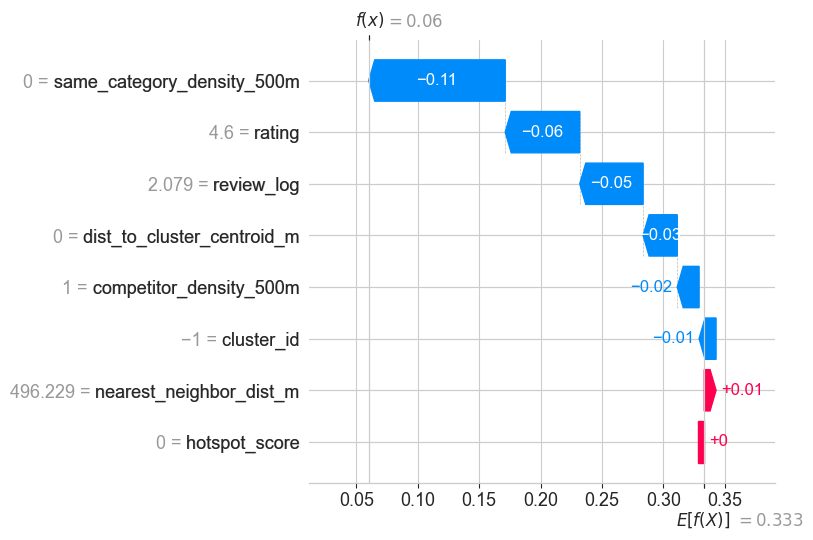

SHAP waterfall disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\rf_shap_waterfall.png
✓ SHAP importance disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\reports\rf_shap_importance.csv


In [31]:
# ── 9.2c SHAP Explainability (Global + Local) ─────────────────────────
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

try:
    import shap
except ImportError:
    shap = None

if shap is None:
    print("SHAP belum terpasang. Jalankan: %pip install shap")
else:
    shap.initjs()

    # Batasi sampel agar proses lebih cepat
    max_samples = 300
    if len(X_test) > max_samples:
        X_shap = X_test.sample(max_samples, random_state=RANDOM_SEED)
    else:
        X_shap = X_test.copy()

    os.makedirs(REPORT_DIR, exist_ok=True)

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_shap)

    # --- Global importance (mean |SHAP|) ---
    shap_values_list = None
    if isinstance(shap_values, list):
        abs_means = [
            pd.DataFrame(vals, columns=X_shap.columns).abs().mean(axis=0)
            for vals in shap_values
        ]
        shap_importance = pd.concat(abs_means, axis=1).mean(axis=1).sort_values(ascending=False)
        shap_values_list = shap_values
    else:
        shap_array = np.array(shap_values)
        if shap_array.ndim == 3:
            # Shape: (n_samples, n_features, n_classes)
            shap_importance = pd.Series(
                np.mean(np.abs(shap_array), axis=(0, 2)),
                index=X_shap.columns
            ).sort_values(ascending=False)
            shap_values_list = [shap_array[:, :, i] for i in range(shap_array.shape[2])]
        else:
            shap_importance = pd.Series(
                np.mean(np.abs(shap_array), axis=0),
                index=X_shap.columns
            ).sort_values(ascending=False)
            shap_values_list = shap_array

    shap_importance_df = shap_importance.reset_index()
    shap_importance_df.columns = ["feature", "mean_abs_shap"]

    print("SHAP Global Importance (mean |SHAP|):")
    display(shap_importance_df)

    # Plot ringkas global
    shap.summary_plot(shap_values_list, X_shap, show=False)
    summary_path = os.path.join(REPORT_DIR, "rf_shap_summary.png")
    plt.tight_layout()
    plt.savefig(summary_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"SHAP summary disimpan: {summary_path}")

    # --- Local explanation (contoh 1 baris) ---
    idx_candidates = np.where(pred == "High")[0]
    row_idx = int(idx_candidates[0]) if len(idx_candidates) > 0 else 0
    x_row = X_test.iloc[[row_idx]]

    shap_row = explainer.shap_values(x_row)
    if isinstance(shap_row, list):
        class_labels = ["Low", "Medium", "High"]
        pred_class = pred[row_idx]
        class_idx = class_labels.index(pred_class) if pred_class in class_labels else 0
        values = shap_row[class_idx][0]
        base_value = explainer.expected_value[class_idx]
    else:
        shap_row_array = np.array(shap_row)
        if shap_row_array.ndim == 3:
            class_labels = ["Low", "Medium", "High"]
            pred_class = pred[row_idx]
            class_idx = class_labels.index(pred_class) if pred_class in class_labels else 0
            values = shap_row_array[0, :, class_idx]
            if isinstance(explainer.expected_value, (list, np.ndarray)):
                base_value = explainer.expected_value[class_idx]
            else:
                base_value = explainer.expected_value
        else:
            values = shap_row_array[0]
            base_value = explainer.expected_value

    explanation = shap.Explanation(
        values=values,
        base_values=base_value,
        data=x_row.iloc[0].values,
        feature_names=x_row.columns.tolist(),
    )

    print(f"Local explanation sample — Pred: {pred[row_idx]}")
    shap.plots.waterfall(explanation, max_display=12, show=False)
    waterfall_path = os.path.join(REPORT_DIR, "rf_shap_waterfall.png")
    plt.tight_layout()
    plt.savefig(waterfall_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"SHAP waterfall disimpan: {waterfall_path}")

    # --- Simpan output ---
    shap_importance_path = os.path.join(REPORT_DIR, "rf_shap_importance.csv")
    shap_importance_df.to_csv(shap_importance_path, index=False)
    print(f"✓ SHAP importance disimpan: {shap_importance_path}")

### 10.3 Simpan Model & Metadata

Ringkas: simpan model RF dan metadata evaluasi.

In [32]:
# ── 9.3 Simpan Model + Metadata ──────────────────────────────────────
import os
import glob
import json
import joblib
import datetime

os.makedirs(MODEL_DIR, exist_ok=True)

existing_models = sorted(glob.glob(os.path.join(MODEL_DIR, "rf_location_reco_v*.joblib")))
version = len(existing_models) + 1
model_path = os.path.join(MODEL_DIR, f"rf_location_reco_v{version}.joblib")
joblib.dump(rf, model_path)

rf_metadata_path = os.path.join(MODEL_DIR, "rf_metadata.json")
rf_metadata = {
    "notebook"         : "02_random_forest_training",
    "timestamp"        : datetime.datetime.now().isoformat(),
    "target_db"        : TARGET_DB_FILE,
    "run_dir"          : RUN_DIR,
    "model_path"       : model_path,
    "features"         : rf_feature_cols,
    "parameters"       : {
        "n_estimators"    : 300,
        "class_weight"    : "balanced",
        "random_seed"     : RANDOM_SEED,
        "spatial_split"   : "grid_1km_group_shuffle",
        "learning_curve_cv": "3-fold GroupKFold on spatial training groups"
    },
    "metrics"          : {
        "f1_macro"        : round(f1_macro, 4),
        "confusion_matrix": cm.tolist(),
        "report"          : report_dict,
        "learning_curve"  : learning_curve_df.to_dict(orient="records")
    },
    "evaluation_reports": {
        "confusion_matrix_plot": cm_path,
        "learning_curve_csv": learning_curve_csv_path,
        "learning_curve_plot": learning_curve_plot_path
    }
}

with open(rf_metadata_path, "w") as f:
    json.dump(rf_metadata, f, indent=2)

print(f"✓ Model disimpan: {model_path}")
print(f"✓ Metadata disimpan: {rf_metadata_path}")

✓ Model disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\models\rf_location_reco_v5.joblib
✓ Metadata disimpan: content/runs\Indonesia.Batam.Kuliner.202406162232\models\rf_metadata.json
